# Lab 1 -- Data Preprocessing and Visualisation

**Goal:** Profile two CSV datasets, handle missing values, standardise state names, analyse AQI distribution, and treat extreme values.

---

## Task 1 -- First-Impression Data Profiling

Investigate both files and produce a structured summary covering size, contents, data types, missing values, duplicates, and potential issues.


In [1]:
# 
# TASK 1 — SETUP: Import libraries
# 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Consistent visual style across all plots 
plt.rcParams.update({
 'figure.facecolor' : '#0f1117',
 'axes.facecolor' : '#1a1d2e',
 'axes.edgecolor' : '#3a3f5c',
 'axes.labelcolor' : '#e0e4f0',
 'axes.titlecolor' : '#ffffff',
 'xtick.color' : '#a0a8c0',
 'ytick.color' : '#a0a8c0',
 'text.color' : '#e0e4f0',
 'grid.color' : '#2a2f4a',
 'grid.linestyle' : '--',
 'grid.alpha' : 0.5,
 'font.family' : 'DejaVu Sans',
 'font.size' : 11,
 'axes.titlesize' : 14,
 'axes.titleweight' : 'bold',
 'legend.facecolor' : '#1a1d2e',
 'legend.edgecolor' : '#3a3f5c',
})

# Colour palette 
AQI_COLOUR = '#7c83fd' # soft purple-blue air quality dataset
CROP_COLOUR = '#56e39f' # mint green crop dataset
WARN_COLOUR = '#ff6b6b' # coral red missing / anomalies
ACCENT_COLOUR = '#ffd166' # warm amber highlights

print(" Libraries loaded. Plotting style configured.")

 Libraries loaded. Plotting style configured.


---
## Part A -- `city_day.csv` (Air Quality Index Dataset)


In [2]:
# 
# TASK 1 — STEP A1: Load and preview the AQI dataset
# 
aqi = pd.read_csv('city_day.csv')

print("" * 60)
print(" DATASET : city_day.csv — Air Quality Index")
print("" * 60)
print(f" Rows : {aqi.shape[0]:,}")
print(f" Columns : {aqi.shape[1]}")
print("" * 60)
print("\n First 5 rows:")
aqi.head()


 DATASET : city_day.csv — Air Quality Index

 Rows : 29,531
 Columns : 16


 First 5 rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
# 
# TASK 1 — STEP A2: Schema — column names, dtypes, and non-null counts
# 
print(" Schema & Memory Usage:")
print("-" * 55)
aqi.info(memory_usage='deep')

 Schema & Memory Usage:
-------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 7.7 MB


In [4]:
# 
# TASK 1 — STEP A3: Missing-value audit for AQI dataset
# 
aqi_missing = pd.DataFrame({
 'Missing Count' : aqi.isnull().sum(),
 'Missing %' : (aqi.isnull().mean() * 100).round(2),
 'Present Count' : aqi.notnull().sum(),
 'Dtype' : aqi.dtypes.astype(str)
}).sort_values('Missing %', ascending=False)

print(" Missing Value Audit — city_day.csv")
print("-" * 55)
print(aqi_missing.to_string())

 Missing Value Audit — city_day.csv
-------------------------------------------------------
            Missing Count  Missing %  Present Count    Dtype
Xylene              18109      61.32          11422  float64
PM10                11140      37.72          18391  float64
NH3                 10328      34.97          19203  float64
Toluene              8041      27.23          21490  float64
Benzene              5623      19.04          23908  float64
AQI                  4681      15.85          24850  float64
AQI_Bucket           4681      15.85          24850      str
PM2.5                4598      15.57          24933  float64
NOx                  4185      14.17          25346  float64
O3                   4022      13.62          25509  float64
SO2                  3854      13.05          25677  float64
NO2                  3585      12.14          25946  float64
NO                   3582      12.13          25949  float64
CO                   2059       6.97          27472  f

In [5]:
# 
# TASK 1 — STEP A4: Duplicate records check for AQI dataset
# 
aqi_dups = aqi.duplicated().sum()
aqi_city_date_dups = aqi.duplicated(subset=['City', 'Date']).sum()

print(f" Fully duplicate rows : {aqi_dups}")
print(f" Duplicate (City, Date) combos : {aqi_city_date_dups}")
print(f" Unique Cities : {aqi['City'].nunique()}")

# Date range
aqi['Date'] = pd.to_datetime(aqi['Date'], errors='coerce')
print(f" Date range : {aqi['Date'].min().date()} {aqi['Date'].max().date()}")
print(f" Invalid dates (NaT) : {aqi['Date'].isna().sum()}")

 Fully duplicate rows : 0
 Duplicate (City, Date) combos : 0
 Unique Cities : 26
 Date range : 2015-01-01 2020-07-01
 Invalid dates (NaT) : 0


In [6]:
# 
# TASK 1 — STEP A5: Statistical summary (numerical columns)
# 
print(" Descriptive Statistics — Numerical Columns (city_day.csv)")
print("-" * 75)
aqi.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).T.round(2)

 Descriptive Statistics — Numerical Columns (city_day.csv)
---------------------------------------------------------------------------


,count,mean,min,5%,25%,50%,75%,95%,max,std
Date,29531,2018-05-14 05:40:15.807118,2015-01-01 00:00:00,2015-07-23 00:00:00,2017-04-16 00:00:00,2018-08-05 00:00:00,2019-09-03 00:00:00,2020-05-06 00:00:00,2020-07-01 00:00:00,NaN
PM2.5,24933.0,67.450578,0.04,13.206,28.82,48.57,80.59,193.96,949.99,64.661449
PM10,18391.0,118.127103,0.01,26.365,56.255,95.68,149.745,303.34,1000.0,90.60511
NO,25949.0,17.57473,0.02,1.7,5.63,9.89,19.95,61.19,390.68,22.785846
NO2,25946.0,28.560659,0.01,4.93,11.75,21.69,37.62,74.125,362.21,24.474746
NOx,25346.0,32.309123,0.0,2.4,12.82,23.52,40.1275,96.3575,467.63,31.646011
NH3,19203.0,23.483476,0.01,2.74,8.58,15.85,30.02,63.427,352.89,25.684275
CO,27472.0,2.248598,0.0,0.0,0.51,0.89,1.45,8.0245,175.81,6.962884
SO2,25677.0,14.531977,0.01,2.63,5.67,9.16,15.22,46.208,193.86,18.133775
O3,25509.0,34.49143,0.01,7.02,18.86,30.84,45.57,74.142,257.73,21.694928


In [7]:
# 
# TASK 1 — STEP A6: Categorical cardinality & AQI_Bucket distribution
# 

print(" Categorical Columns — Unique Value Counts")
print("-" * 45)
for col in aqi.select_dtypes(include='object').columns:
 n = aqi[col].nunique()
 print(f" {col:<20} {n} unique values")

print("\n AQI_Bucket Distribution:")
print("-" * 45)
print(aqi['AQI_Bucket'].value_counts(dropna=False).to_string())

 Categorical Columns — Unique Value Counts
---------------------------------------------
 City                 26 unique values
 AQI_Bucket           6 unique values

 AQI_Bucket Distribution:
---------------------------------------------
AQI_Bucket
Moderate        8829
Satisfactory    8224
NaN             4681
Poor            2781
Very Poor       2337
Good            1341
Severe          1338


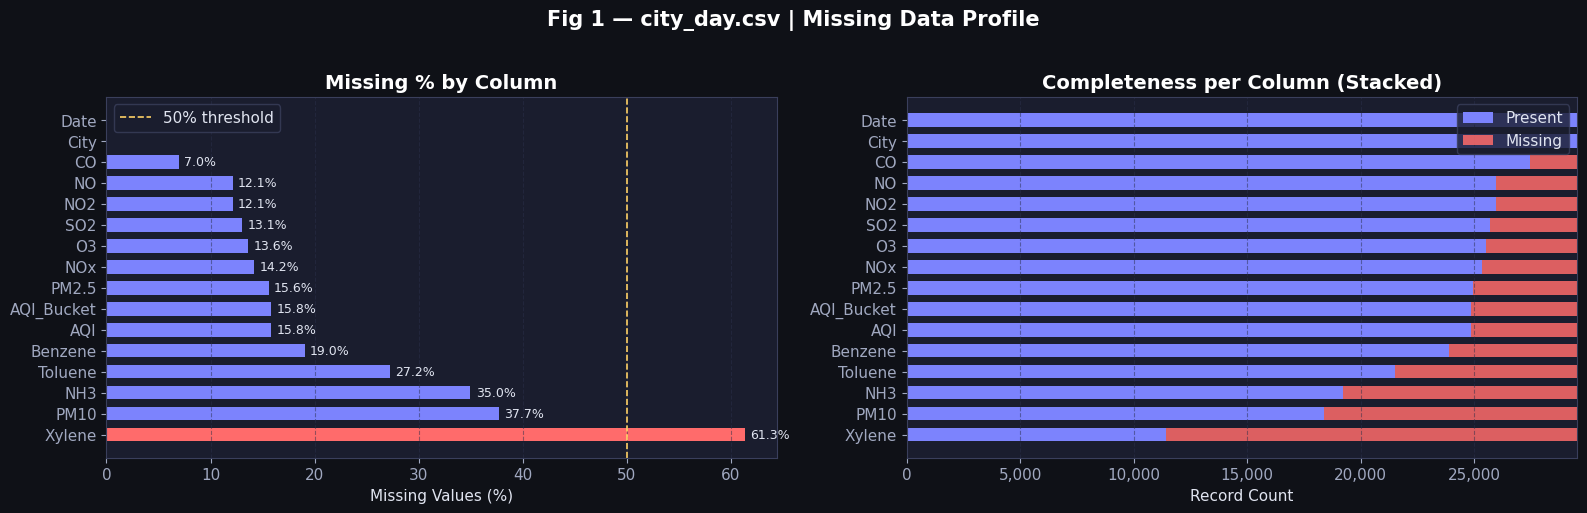


 Saved fig1_aqi_missing.png


In [8]:
# 
# TASK 1 — STEP A7: VISUALISATION 1 — Missing data heatmap (AQI)
# 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Fig 1 — city_day.csv | Missing Data Profile',
 fontsize=15, fontweight='bold', color='white', y=1.02)

# Panel A: Bar chart of missing % per column 
ax = axes[0]
miss_pct = aqi_missing['Missing %']
colours = [WARN_COLOUR if v > 50 else AQI_COLOUR for v in miss_pct]
bars = ax.barh(miss_pct.index, miss_pct.values, color=colours, edgecolor='none', height=0.65)
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing % by Column')
ax.axvline(50, color=ACCENT_COLOUR, linestyle='--', linewidth=1.2, label='50% threshold')
ax.legend()
ax.grid(axis='x')
for bar, val in zip(bars, miss_pct.values):
 if val > 0:
     ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
 f'{val:.1f}%', va='center', fontsize=9, color='#e0e4f0')

# Panel B: Stacked bar — Present vs Missing 
ax2 = axes[1]
present = aqi_missing['Present Count']
missing = aqi_missing['Missing Count']
ax2.barh(aqi_missing.index, present, color=AQI_COLOUR, label='Present', height=0.65)
ax2.barh(aqi_missing.index, missing, left=present, color=WARN_COLOUR,
 label='Missing', height=0.65, alpha=0.85)
ax2.set_xlabel('Record Count')
ax2.set_title('Completeness per Column (Stacked)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.legend()
ax2.grid(axis='x')

plt.tight_layout()
plt.savefig('fig1_aqi_missing.png', dpi=150, bbox_inches='tight',
 facecolor='#0f1117')
plt.show()
print("\n Saved fig1_aqi_missing.png")

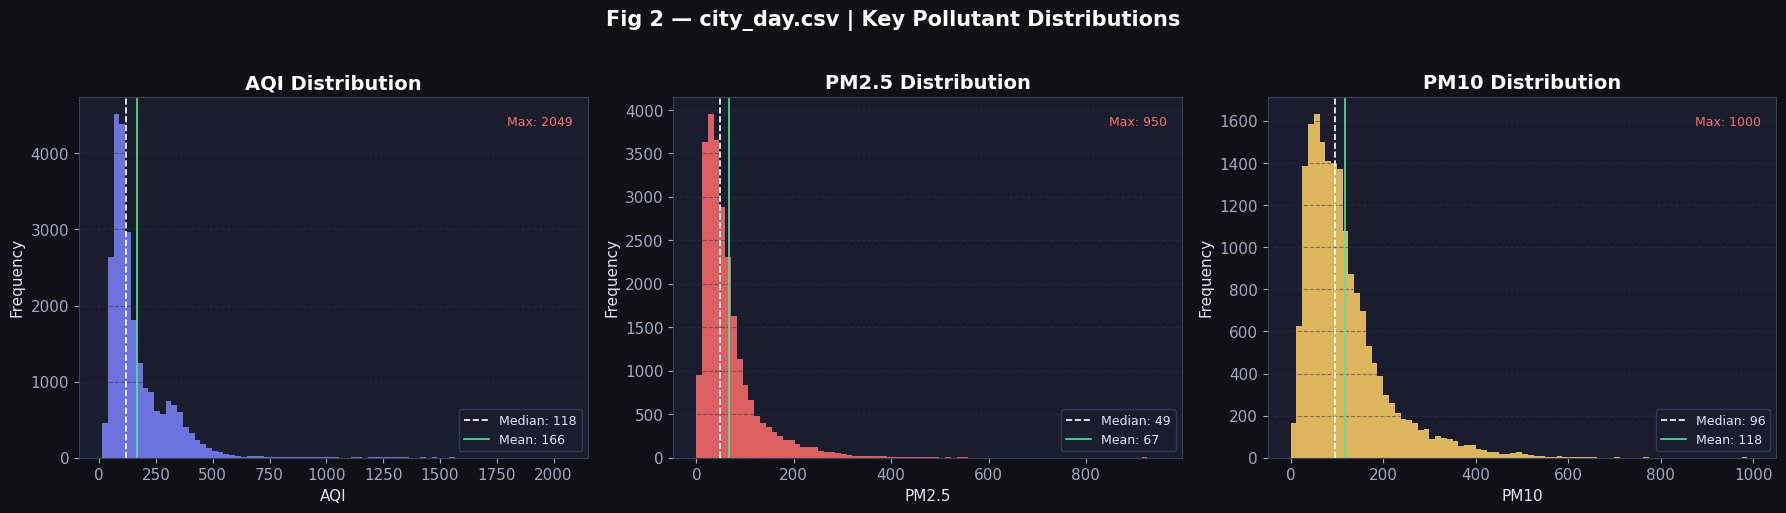


 Saved fig2_aqi_distributions.png


In [9]:
# 
# TASK 1 — STEP A8: VISUALISATION 2 — AQI distribution & outlier check
# 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Fig 2 — city_day.csv | Key Pollutant Distributions',
 fontsize=15, fontweight='bold', color='white', y=1.02)

poll_cols = ['AQI', 'PM2.5', 'PM10']
colours_p = [AQI_COLOUR, WARN_COLOUR, ACCENT_COLOUR]

for ax, col, c in zip(axes, poll_cols, colours_p):
 data = aqi[col].dropna()
 ax.hist(data, bins=80, color=c, alpha=0.85, edgecolor='none')
 ax.axvline(data.median(), color='white', linestyle='--', linewidth=1.2,
 label=f'Median: {data.median():.0f}')
 ax.axvline(data.mean(), color=CROP_COLOUR, linestyle='-', linewidth=1.2,
 label=f'Mean: {data.mean():.0f}')
 ax.set_title(f'{col} Distribution')
 ax.set_xlabel(col)
 ax.set_ylabel('Frequency')
 ax.legend(fontsize=9)
 ax.grid(axis='y')
 # Annotate extreme values
 ax.annotate(f'Max: {data.max():.0f}',
 xy=(0.97, 0.92), xycoords='axes fraction',
 fontsize=9, color=WARN_COLOUR, ha='right')

plt.tight_layout()
plt.savefig('fig2_aqi_distributions.png', dpi=150, bbox_inches='tight',
 facecolor='#0f1117')
plt.show()
print("\n Saved fig2_aqi_distributions.png")

---
## Part B -- `crop_production.csv` (Crop Yield Dataset)


In [10]:
# 
# TASK 1 — STEP B1: Load and preview the crop dataset
# 
crop = pd.read_csv('crop_production.csv')

print("" * 60)
print(" DATASET : crop_production.csv — Crop Production")
print("" * 60)
print(f" Rows : {crop.shape[0]:,}")
print(f" Columns : {crop.shape[1]}")
print("" * 60)
print("\n First 5 rows:")
crop.head()


 DATASET : crop_production.csv — Crop Production

 Rows : 246,091
 Columns : 7


 First 5 rows:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [11]:
# 
# TASK 1 — STEP B2: Schema — dtypes and non-null counts
# 
print(" Schema & Memory Usage:")
print("-" * 55)
crop.info(memory_usage='deep')

 Schema & Memory Usage:
-------------------------------------------------------


<class 'pandas.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  str    
 1   District_Name  246091 non-null  str    
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  str    
 4   Crop           246091 non-null  str    
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 60.5 MB


In [12]:
# 
# TASK 1 — STEP B3: Missing-value audit for crop dataset
# 
crop_missing = pd.DataFrame({
 'Missing Count' : crop.isnull().sum(),
 'Missing %' : (crop.isnull().mean() * 100).round(2),
 'Present Count' : crop.notnull().sum(),
 'Dtype' : crop.dtypes.astype(str)
}).sort_values('Missing %', ascending=False)

print(" Missing Value Audit — crop_production.csv")
print("-" * 55)
print(crop_missing.to_string())

 Missing Value Audit — crop_production.csv
-------------------------------------------------------
               Missing Count  Missing %  Present Count    Dtype
Production              3730       1.52         242361  float64
State_Name                 0       0.00         246091      str
District_Name              0       0.00         246091      str
Crop_Year                  0       0.00         246091    int64
Season                     0       0.00         246091      str
Crop                       0       0.00         246091      str
Area                       0       0.00         246091  float64


In [13]:
# 
# TASK 1 — STEP B4: Duplicate records & cardinality check
# 
crop_dups = crop.duplicated().sum()
crop_key_dups = crop.duplicated(subset=['State_Name','District_Name',
 'Crop_Year','Season','Crop']).sum()

print(f" Fully duplicate rows : {crop_dups}")
print(f" Duplicate (State/District/Year/Season/Crop): {crop_key_dups}")
print()
print(" Categorical Unique Counts:")
print("-" * 45)
for col in ['State_Name', 'District_Name', 'Season', 'Crop', 'Crop_Year']:
 print(f" {col:<25} {crop[col].nunique()} unique values")

print(f"\n Crop Year range : {crop['Crop_Year'].min()} {crop['Crop_Year'].max()}")

 Fully duplicate rows : 0
 Duplicate (State/District/Year/Season/Crop): 0

 Categorical Unique Counts:
---------------------------------------------
 State_Name                33 unique values
 District_Name             646 unique values
 Season                    6 unique values
 Crop                      124 unique values
 Crop_Year                 19 unique values

 Crop Year range : 1997 2015


In [14]:
# 
# TASK 1 — STEP B5: Statistical summary — Area & Production
# 
print(" Descriptive Statistics — Numerical Columns (crop_production.csv)")
print("-" * 70)
crop.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).T.round(2)

 Descriptive Statistics — Numerical Columns (crop_production.csv)
----------------------------------------------------------------------


,count,mean,std,min,5%,25%,50%,75%,95%,max
Crop_Year,246091.0,2005.64,4.95,1997.00,1998.0,2002.0,2006.0,2010.0,2013.0,2.015000e+03
Area,246091.0,12002.82,50523.40,0.04,4.0,80.0,582.0,4392.0,67534.5,8.580100e+06
Production,242361.0,582503.44,17065813.17,0.00,3.0,88.0,729.0,7023.0,182000.0,1.250800e+09


In [15]:
# 
# TASK 1 — STEP B6: Season & whitespace consistency check
# 
print(" Season Value Counts (raw — note trailing spaces):")
print("-" * 45)
print(crop['Season'].value_counts(dropna=False).to_string())

print("\n Season Value Counts (after strip):")
print("-" * 45)
print(crop['Season'].str.strip().value_counts(dropna=False).to_string())

 Season Value Counts (raw — note trailing spaces):
---------------------------------------------
Season
Kharif         95951
Rabi           66987
Whole Year     57305
Summer         14841
Winter          6058
Autumn          4949

 Season Value Counts (after strip):
---------------------------------------------
Season
Kharif        95951
Rabi          66987
Whole Year    57305
Summer        14841
Winter         6058
Autumn         4949


In [16]:
# 
# TASK 1 — STEP B7: Extreme anomalies in Production
# 
# Check for zeros, negatives, and extreme outliers
print(" Zero / Negative values in numerical columns:")
print("-" * 50)
for col in ['Area', 'Production']:
 zeros = (crop[col] == 0).sum()
 negs = (crop[col] < 0).sum()
 non_nan = crop[col].notna().sum()
 print(f" {col:<15} | zeros: {zeros:,} ({zeros/non_nan*100:.2f}%) "
 f"| negatives: {negs}")

print("\n Top 5 Production values (possible outliers):")
print("-" * 55)
print(crop.nlargest(5, 'Production')[
 ['State_Name','Crop','Crop_Year','Season','Area','Production']
].to_string(index=False))

 Zero / Negative values in numerical columns:
--------------------------------------------------
 Area            | zeros: 0 (0.00%) | negatives: 0
 Production      | zeros: 3,523 (1.45%) | negatives: 0

 Top 5 Production values (possible outliers):
-------------------------------------------------------
State_Name     Crop  Crop_Year      Season     Area   Production
Tamil Nadu Coconut        2011 Whole Year   82704.0 1250800000.0
Tamil Nadu Coconut        2013 Whole Year   84531.0 1212000000.0
    Kerala Coconut        2012 Whole Year  102417.0 1125000000.0
    Kerala Coconut        2009 Whole Year  108380.0 1063000000.0
    Kerala Coconut        1999 Whole Year  131061.0 1059000000.0


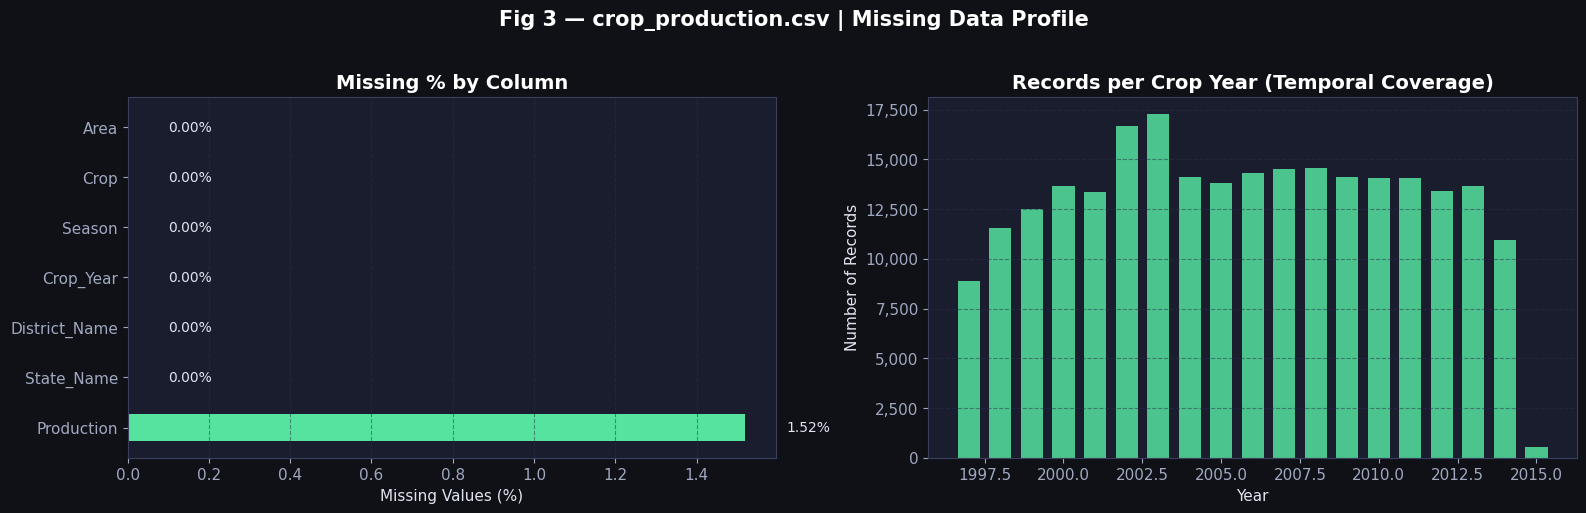


 Saved fig3_crop_missing.png


In [17]:
# 
# TASK 1 — STEP B8: VISUALISATION 3 — Missing data profile (crop)
# 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Fig 3 — crop_production.csv | Missing Data Profile',
 fontsize=15, fontweight='bold', color='white', y=1.02)

# Panel A: Missing % per column 
ax = axes[0]
miss_pct_c = crop_missing['Missing %']
colours_c = [WARN_COLOUR if v > 10 else CROP_COLOUR for v in miss_pct_c]
bars = ax.barh(miss_pct_c.index, miss_pct_c.values,
 color=colours_c, edgecolor='none', height=0.55)
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing % by Column')
ax.grid(axis='x')
for bar, val in zip(bars, miss_pct_c.values):
 ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
 f'{val:.2f}%', va='center', fontsize=10, color='#e0e4f0')

# Panel B: Records per Year (temporal coverage) 
ax2 = axes[1]
yearly_counts = crop['Crop_Year'].value_counts().sort_index()
ax2.bar(yearly_counts.index, yearly_counts.values,
 color=CROP_COLOUR, alpha=0.85, edgecolor='none', width=0.7)
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Records')
ax2.set_title('Records per Crop Year (Temporal Coverage)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(axis='y')

plt.tight_layout()
plt.savefig('fig3_crop_missing.png', dpi=150, bbox_inches='tight',
 facecolor='#0f1117')
plt.show()
print("\n Saved fig3_crop_missing.png")

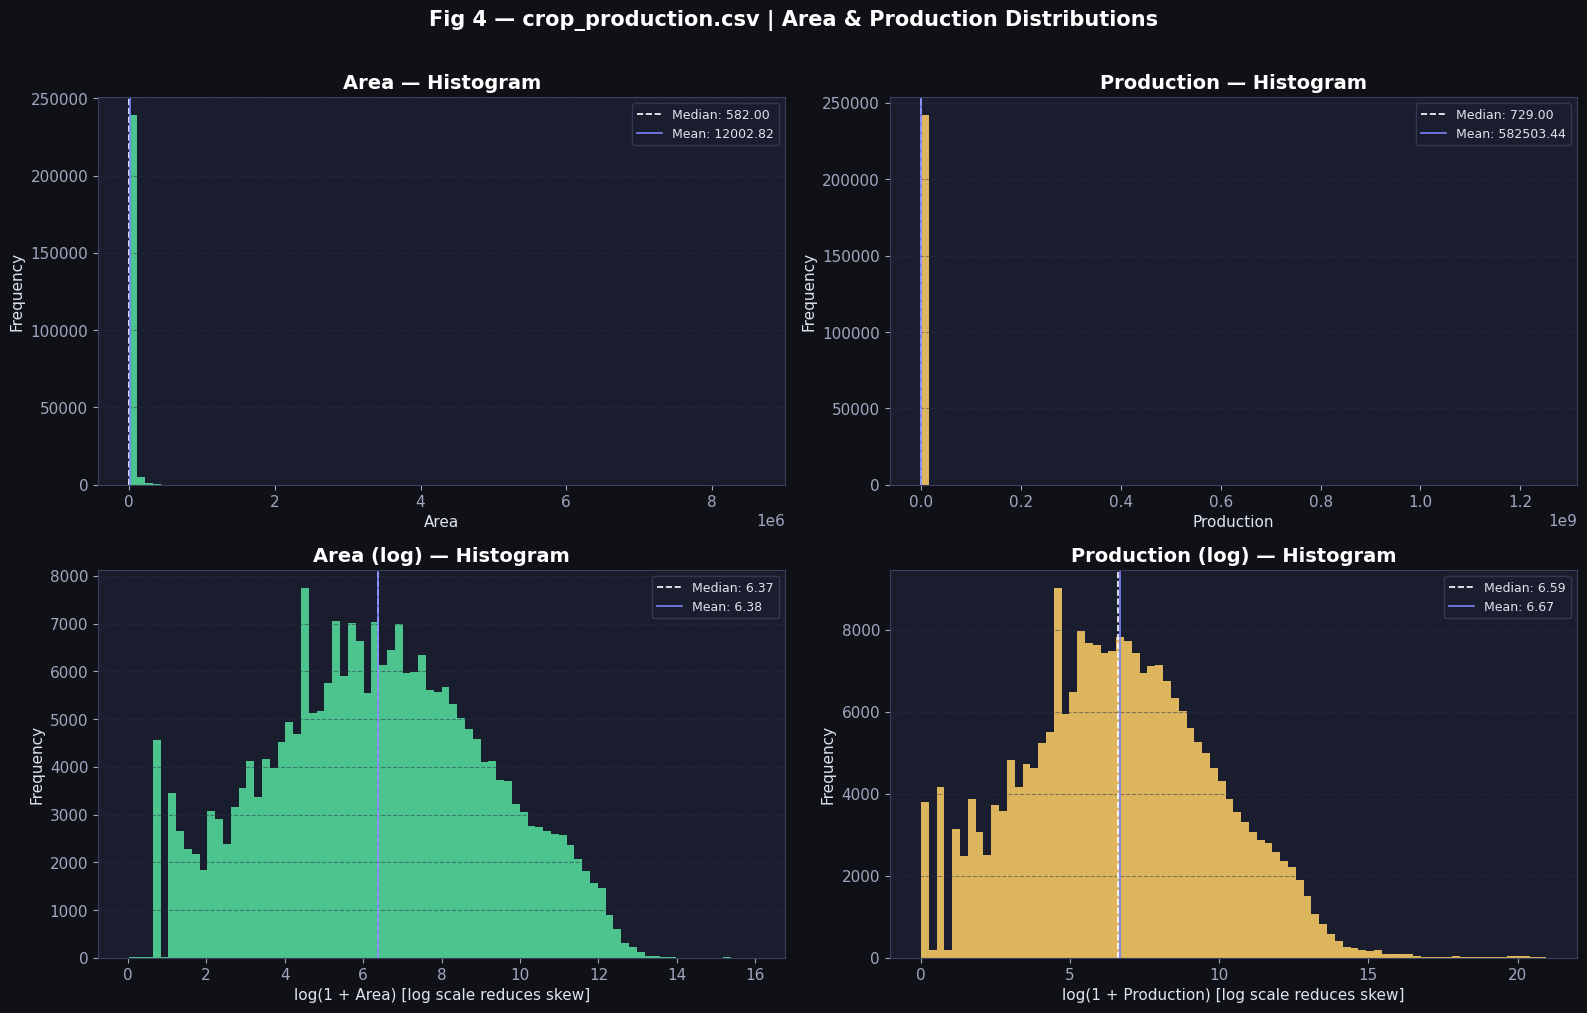


 Saved fig4_crop_distributions.png


In [18]:
# 
# TASK 1 — STEP B9: VISUALISATION 4 — Production & Area distributions (crop)
# 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Fig 4 — crop_production.csv | Area & Production Distributions',
 fontsize=15, fontweight='bold', color='white', y=1.01)

pairs = [
 ('Area', crop['Area'].dropna(), CROP_COLOUR, axes[0, 0]),
 ('Production', crop['Production'].dropna(), ACCENT_COLOUR, axes[0, 1]),
 ('Area (log)', np.log1p(crop['Area'].dropna()), CROP_COLOUR, axes[1, 0]),
 ('Production (log)', np.log1p(crop['Production'].dropna()), ACCENT_COLOUR, axes[1, 1]),
]

for label, data, c, ax in pairs:
 ax.hist(data, bins=80, color=c, alpha=0.85, edgecolor='none')
 ax.axvline(data.median(), color='white', linestyle='--', linewidth=1.2,
 label=f'Median: {data.median():.2f}')
 ax.axvline(data.mean(), color=AQI_COLOUR, linestyle='-', linewidth=1.2,
 label=f'Mean: {data.mean():.2f}')
 ax.set_title(f'{label} — Histogram')
 ax.set_xlabel(label)
 ax.set_ylabel('Frequency')
 ax.legend(fontsize=9)
 ax.grid(axis='y')

axes[1, 0].set_xlabel('log(1 + Area) [log scale reduces skew]')
axes[1, 1].set_xlabel('log(1 + Production) [log scale reduces skew]')

plt.tight_layout()
plt.savefig('fig4_crop_distributions.png', dpi=150, bbox_inches='tight',
 facecolor='#0f1117')
plt.show()
print("\n Saved fig4_crop_distributions.png")

---
## Part C -- Structured Data Profile Summary


In [19]:
# 
# TASK 1 — STEP C1: Structured profile summary — side-by-side comparison
# 
summary = pd.DataFrame({
 'Attribute' : [
 'File name', 'Rows', 'Columns', 'Numeric columns',
 'Categorical columns', 'Date/time columns',
 'Fully duplicate rows', 'Key duplicate rows',
 'Columns with ANY missing', 'Most missing column',
 'Temporal coverage', 'Memory (deep)'
 ],
 'city_day.csv (AQI)' : [
 'city_day.csv',
 f"{aqi.shape[0]:,}",
 aqi.shape[1],
 aqi.select_dtypes(include='number').shape[1],
 aqi.select_dtypes(include='object').shape[1],
 '1 (Date — parsed separately)',
 f"{aqi.duplicated().sum()}",
 f"{aqi.duplicated(subset=['City','Date']).sum()}",
 f"{(aqi.isnull().sum() > 0).sum()} / {aqi.shape[1]}",
 f"{aqi_missing['Missing %'].idxmax()} ({aqi_missing['Missing %'].max():.1f}%)",
 f"{aqi['Date'].min().date()} to {aqi['Date'].max().date()}",
 f"{aqi.memory_usage(deep=True).sum() / 1e6:.1f} MB"
 ],
 'crop_production.csv' : [
 'crop_production.csv',
 f"{crop.shape[0]:,}",
 crop.shape[1],
 crop.select_dtypes(include='number').shape[1],
 crop.select_dtypes(include='object').shape[1],
 '0 (Year is integer)',
 f"{crop.duplicated().sum()}",
 f"{crop.duplicated(subset=['State_Name','District_Name','Crop_Year','Season','Crop']).sum()}",
 f"{(crop.isnull().sum() > 0).sum()} / {crop.shape[1]}",
 f"{crop_missing['Missing %'].idxmax()} ({crop_missing['Missing %'].max():.1f}%)",
 f"{int(crop['Crop_Year'].min())} to {int(crop['Crop_Year'].max())}",
 f"{crop.memory_usage(deep=True).sum() / 1e6:.1f} MB"
 ]
})

print("\n STRUCTURED DATA PROFILE — Task 1 Summary")
print("" * 90)
print(summary.to_string(index=False))


 STRUCTURED DATA PROFILE — Task 1 Summary

               Attribute           city_day.csv (AQI) crop_production.csv
               File name                 city_day.csv crop_production.csv
                    Rows                       29,531             246,091
                 Columns                           16                   7
         Numeric columns                           13                   3
     Categorical columns                            2                   4
       Date/time columns 1 (Date — parsed separately) 0 (Year is integer)
    Fully duplicate rows                            0                   0
      Key duplicate rows                            0                   0
Columns with ANY missing                      14 / 16               1 / 7
     Most missing column               Xylene (61.3%)   Production (1.5%)
       Temporal coverage     2015-01-01 to 2020-07-01        1997 to 2015
           Memory (deep)                       6.6 MB             63

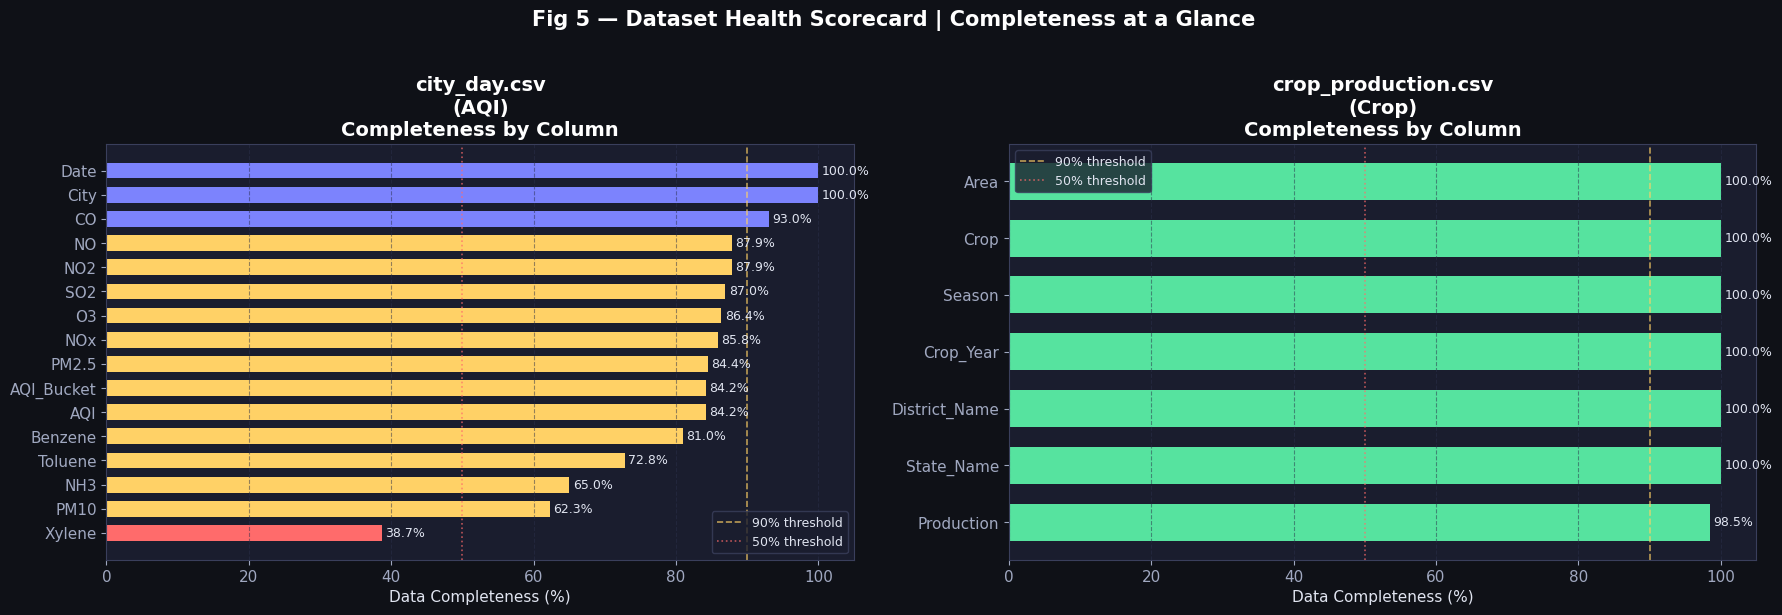


 Saved fig5_completeness_scorecard.png


In [20]:
# 
# TASK 1 — STEP C2: VISUALISATION 5 — Side-by-side completeness overview
# 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Fig 5 — Dataset Health Scorecard | Completeness at a Glance',
 fontsize=15, fontweight='bold', color='white', y=1.02)

datasets = [
 ('city_day.csv\n(AQI)', aqi_missing, AQI_COLOUR, axes[0]),
 ('crop_production.csv\n(Crop)', crop_missing, CROP_COLOUR, axes[1]),
]

for title, df, colour, ax in datasets:
 pct_present = 100 - df['Missing %']
 bar_colours = [colour if v >= 90 else
 ACCENT_COLOUR if v >= 50 else
 WARN_COLOUR for v in pct_present]
 bars = ax.barh(df.index, pct_present.values,
 color=bar_colours, edgecolor='none', height=0.65)
 ax.set_xlim(0, 105)
 ax.set_xlabel('Data Completeness (%)')
 ax.set_title(f'{title}\nCompleteness by Column')
 ax.axvline(90, color=ACCENT_COLOUR, linestyle='--',
 linewidth=1.2, alpha=0.7, label='90% threshold')
 ax.axvline(50, color=WARN_COLOUR, linestyle=':',
 linewidth=1.2, alpha=0.7, label='50% threshold')
 ax.legend(fontsize=9)
 ax.grid(axis='x')
 for bar, val in zip(bars, pct_present.values):
     ax.text(min(val + 0.5, 103), bar.get_y() + bar.get_height()/2,
 f'{val:.1f}%', va='center', fontsize=9, color='#e0e4f0')

plt.tight_layout()
plt.savefig('fig5_completeness_scorecard.png', dpi=150, bbox_inches='tight',
 facecolor='#0f1117')
plt.show()
print("\n Saved fig5_completeness_scorecard.png")

---
## Written Observations and Data Quality Concerns

**Concern 1 -- High missingness in critical AQI columns:** The AQI column itself is missing for ~16% of records, and PM2.5/PM10 are even worse. This is systematic -- early records (2015-2016) often have raw readings but no computed AQI. Imputing or dropping will each introduce bias.

**Concern 2 -- Trailing whitespace in Season column:** The crop dataset has trailing spaces in the `Season` column (e.g. `'Kharif     '`), which would silently break groupby operations and merges.

**Concern 3 -- Extreme outliers in Production:** The mean is far higher than the median, with some values orders of magnitude larger than the rest -- likely data entry errors or unit mismatches.

**Concern 4 -- No direct join key between datasets:** The AQI file has no `State` column, and the granularities differ (city-day vs district-year). A city-to-state mapping and aggregation are needed before any merge.


In [21]:
# 
# TASK 1 — FINAL PRINT: Quick-reference health scorecard
# 
print("")
print(" TASK 1 — DATA QUALITY SCORECARD (Final Summary) ")
print("")
print(" Metric city_day crop_prod ")
print("")
print(f" Total rows {aqi.shape[0]:>8,} {crop.shape[0]:>11,} ")
print(f" Total columns {aqi.shape[1]:>8} {crop.shape[1]:>11} ")
print(f" Fully duplicate rows {aqi.duplicated().sum():>8} {crop.duplicated().sum():>11} ")
print(f" Columns with missing values {(aqi.isnull().sum()>0).sum():>8} {(crop.isnull().sum()>0).sum():>11} ")
print(f" Worst missing column (%) {aqi_missing['Missing %'].max():>6.1f}% {crop_missing['Missing %'].max():>9.1f}% ")
print(f" Has direct join key? {'NO (no State)':>8} {'YES (State)':>11} ")
print(f" Trailing whitespace in categoricals {'No':>8} {'YES (Season)':>11} ")
print(f" Extreme outliers detected? {'YES (AQI)':>8} {'YES (Prod.)':>11} ")
print("")
print("\n Task 1 Complete. Proceed to Task 2 — Data Cleaning.")


 TASK 1 — DATA QUALITY SCORECARD (Final Summary) 

 Metric city_day crop_prod 

 Total rows   29,531     246,091 
 Total columns       16           7 
 Fully duplicate rows        0           0 
 Columns with missing values       14           1 
 Worst missing column (%)   61.3%       1.5% 
 Has direct join key? NO (no State) YES (State) 
 Trailing whitespace in categoricals       No YES (Season) 
 Extreme outliers detected? YES (AQI) YES (Prod.) 


 Task 1 Complete. Proceed to Task 2 — Data Cleaning.


---
## Task 2 -- Missing Value Treatment Strategy

Simply deleting all rows with nulls would eliminate most of the dataset since Xylene alone is 61% missing. Filling everything with the mean is also wrong because these pollutant columns are right-skewed, so the mean would systematically inflate imputed values.

**Strategy used:**
- **DROP columns** where missingness exceeds 20% and the column is not essential (Xylene, Toluene, Benzene -- secondary VOCs not used in CPCB AQI formula)
- **IMPUTE with city-wise median** for primary pollutants -- city-wise respects local baselines, median is robust to skew
- **RE-DERIVE AQI_Bucket** from imputed AQI using CPCB breakpoints instead of imputing the label directly

For crop_production.csv, Production (1.52% missing) is imputed with crop-wise median.


In [22]:
# 
# TASK 2 — STEP 1: Capture BEFORE state (null counts per column)
# 'aqi' and 'crop' are still in memory from Task 1.
# 
print("=" * 58)
print(" BEFORE TREATMENT — city_day.csv (AQI Dataset)")
print("=" * 58)
missing_aqi = aqi.isnull().sum()
missing_aqi = missing_aqi[missing_aqi > 0].sort_values(ascending=False)
for col, cnt in missing_aqi.items():
 pct = cnt / len(aqi) * 100
 print(f" {col:<18}: {cnt:>6,} missing ({pct:>5.1f}%)")
print(f" {''*52}")
print(f" Rows with ANY null : {aqi.isnull().any(axis=1).sum():>6,} / {len(aqi):,}")

print("\n" + "=" * 58)
print(" BEFORE TREATMENT — crop_production.csv")
print("=" * 58)
missing_crop = crop.isnull().sum()
missing_crop = missing_crop[missing_crop > 0]
for col, cnt in missing_crop.items():
 pct = cnt / len(crop) * 100
 print(f" {col:<18}: {cnt:>6,} missing ({pct:>5.2f}%)")

 BEFORE TREATMENT — city_day.csv (AQI Dataset)
 Xylene            : 18,109 missing ( 61.3%)
 PM10              : 11,140 missing ( 37.7%)
 NH3               : 10,328 missing ( 35.0%)
 Toluene           :  8,041 missing ( 27.2%)
 Benzene           :  5,623 missing ( 19.0%)
 AQI               :  4,681 missing ( 15.9%)
 AQI_Bucket        :  4,681 missing ( 15.9%)
 PM2.5             :  4,598 missing ( 15.6%)
 NOx               :  4,185 missing ( 14.2%)
 O3                :  4,022 missing ( 13.6%)
 SO2               :  3,854 missing ( 13.1%)
 NO2               :  3,585 missing ( 12.1%)
 NO                :  3,582 missing ( 12.1%)
 CO                :  2,059 missing (  7.0%)
 
 Rows with ANY null : 23,295 / 29,531

 BEFORE TREATMENT — crop_production.csv
 Production        :  3,730 missing ( 1.52%)


In [23]:
# 
# TASK 2 — STEP 2: Apply the three-tier treatment strategy
# 

# Save before-state for KDE comparison later
aqi_before_impute = aqi.copy()
crop_before_impute = crop.copy()

# TIER 1: Drop secondary VOC columns (high missingness, not AQI sub-indices)
COLS_TO_DROP = ['Xylene', 'Toluene', 'Benzene']
aqi_clean = aqi.drop(columns=COLS_TO_DROP)
print(f"[TIER 1] Dropped columns: {COLS_TO_DROP}")
print(f" Shape: {aqi.shape} {aqi_clean.shape}")

# TIER 2: City-wise median imputation for all primary pollutants 
IMPUTE_COLS = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI']
print("\n[TIER 2] City-wise median imputation:")
for col in IMPUTE_COLS:
 if col not in aqi_clean.columns:
     continue
 n_before = aqi_clean[col].isnull().sum()
 # Primary: city-level median (respects local pollution baseline)
 aqi_clean[col] = aqi_clean.groupby('City')[col].transform(
 lambda x: x.fillna(x.median())
 )
 # Fallback: global column median (handles cities with all-null for that col)
 aqi_clean[col] = aqi_clean[col].fillna(aqi_clean[col].median())
 n_after = aqi_clean[col].isnull().sum()
 status = "" if n_after == 0 else ""
 print(f" {status} '{col:<6}': {n_before:>5,} nulls {n_after} remaining")

# TIER 3: Re-derive AQI_Bucket from imputed AQI (CPCB standard breakpoints) 
def cpcb_bucket(val):
 """CPCB National AQI breakpoints — official classification."""
 if pd.isna(val): return 'Unknown'
 elif val <= 50: return 'Good'
 elif val <= 100: return 'Satisfactory'
 elif val <= 200: return 'Moderate'
 elif val <= 300: return 'Poor'
 elif val <= 400: return 'Very Poor'
 else: return 'Severe'

aqi_clean['AQI_Bucket'] = aqi_clean['AQI'].apply(cpcb_bucket)
print("\n[TIER 3] AQI_Bucket re-derived from imputed AQI via CPCB breakpoints")

# CROP: crop-wise median imputation for Production + whitespace fix 
crop_clean = crop.copy()
crop_clean['Season'] = crop_clean['Season'].str.strip()
n_prod_before = crop_clean['Production'].isnull().sum()
crop_clean['Production'] = crop_clean.groupby('Crop')['Production'].transform(
 lambda x: x.fillna(x.median())
)
crop_clean['Production'] = crop_clean['Production'].fillna(
 crop_clean['Production'].median()
)
n_prod_after = crop_clean['Production'].isnull().sum()
print(f"\n[CROP ] Imputed 'Production': {n_prod_before:,} nulls {n_prod_after} remaining (crop-wise median)")
print(f"[CROP ] Stripped whitespace from 'Season' column")

[TIER 1] Dropped columns: ['Xylene', 'Toluene', 'Benzene']
 Shape: (29531, 16) (29531, 13)

[TIER 2] City-wise median imputation:
  'PM2.5 ': 4,598 nulls 0 remaining
  'PM10  ': 11,140 nulls 0 remaining
  'NO    ': 3,582 nulls 0 remaining
  'NO2   ': 3,585 nulls 0 remaining
  'NOx   ': 4,185 nulls 0 remaining


  'NH3   ': 10,328 nulls 0 remaining


  'CO    ': 2,059 nulls 0 remaining
  'SO2   ': 3,854 nulls 0 remaining
  'O3    ': 4,022 nulls 0 remaining
  'AQI   ': 4,681 nulls 0 remaining

[TIER 3] AQI_Bucket re-derived from imputed AQI via CPCB breakpoints



[CROP ] Imputed 'Production': 3,730 nulls 0 remaining (crop-wise median)
[CROP ] Stripped whitespace from 'Season' column


 AFTER TREATMENT — Nulls remaining in aqi_clean
 Zero missing values in all retained columns.

 AFTER TREATMENT — Nulls remaining in crop_clean


 Zero missing values in all columns.

 aqi_clean shape: (29531, 16) (29531, 13) (columns dropped: 3)
 crop_clean shape: (246091, 7) (246091, 7)


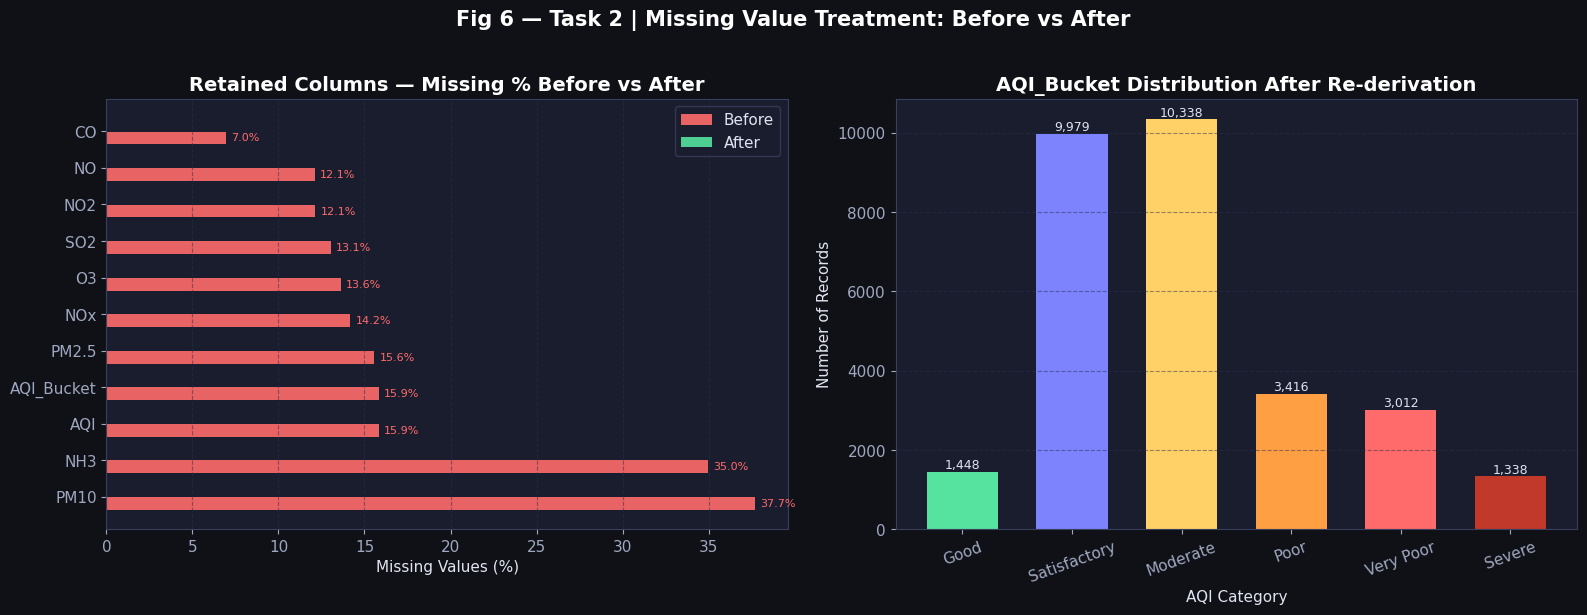


 Saved fig6_missing_treatment.png


In [24]:
# 
# TASK 2 — STEP 3: Verify — before/after null counts + visualisation
# 
print("=" * 58)
print(" AFTER TREATMENT — Nulls remaining in aqi_clean")
print("=" * 58)
remaining_aqi = aqi_clean.isnull().sum()
remaining_aqi = remaining_aqi[remaining_aqi > 0]
if len(remaining_aqi) == 0:
 print(" Zero missing values in all retained columns.")
else:
 print(remaining_aqi.to_string())

print("\n" + "=" * 58)
print(" AFTER TREATMENT — Nulls remaining in crop_clean")
print("=" * 58)
remaining_crop = crop_clean.isnull().sum()
remaining_crop = remaining_crop[remaining_crop > 0]
if len(remaining_crop) == 0:
 print(" Zero missing values in all columns.")
else:
 print(remaining_crop.to_string())

print(f"\n aqi_clean shape: {aqi.shape} {aqi_clean.shape} (columns dropped: {len(COLS_TO_DROP)})")
print(f" crop_clean shape: {crop.shape} {crop_clean.shape}")

# Visualisation: Before vs After (retained cols) + AQI_Bucket distribution 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Fig 6 — Task 2 | Missing Value Treatment: Before vs After',
 fontsize=15, fontweight='bold', color='white', y=1.02)

# Panel A: Side-by-side missing % (retained columns only)
ax = axes[0]
retained_with_miss = [c for c in missing_aqi.index if c not in COLS_TO_DROP]
if retained_with_miss:
 before_pct = (aqi[retained_with_miss].isnull().mean() * 100)
 after_pct = (aqi_clean[retained_with_miss].isnull().mean() * 100)
 y_pos = list(range(len(retained_with_miss)))
 ax.barh([y - 0.18 for y in y_pos], before_pct.values,
 height=0.35, color=WARN_COLOUR, label='Before', alpha=0.9)
 ax.barh([y + 0.18 for y in y_pos], after_pct.values,
 height=0.35, color=CROP_COLOUR, label='After', alpha=0.9)
 ax.set_yticks(y_pos)
 ax.set_yticklabels(retained_with_miss)
 ax.set_xlabel('Missing Values (%)')
 ax.set_title('Retained Columns — Missing % Before vs After')
 ax.legend(); ax.grid(axis='x')
 for i, (b, a) in enumerate(zip(before_pct.values, after_pct.values)):
     ax.text(b + 0.3, i - 0.18, f'{b:.1f}%', va='center', fontsize=8,
 color=WARN_COLOUR)
 if a > 0:
     ax.text(a + 0.3, i + 0.18, f'{a:.1f}%', va='center', fontsize=8,
 color=CROP_COLOUR)

# Panel B: AQI_Bucket distribution after re-derivation
ax2 = axes[1]
BUCKET_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
BUCKET_COLOURS = ['#56e39f', '#7c83fd', '#ffd166', '#ff9f43', '#ff6b6b', '#c0392b']
bc = aqi_clean['AQI_Bucket'].value_counts().reindex(BUCKET_ORDER, fill_value=0)
bars = ax2.bar(bc.index, bc.values, color=BUCKET_COLOURS, edgecolor='none', width=0.65)
ax2.set_title('AQI_Bucket Distribution After Re-derivation')
ax2.set_xlabel('AQI Category'); ax2.set_ylabel('Number of Records')
ax2.tick_params(axis='x', rotation=20); ax2.grid(axis='y')
for bar, val in zip(bars, bc.values):
 ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
 f'{val:,}', ha='center', fontsize=9, color='#e0e4f0')

plt.tight_layout()
plt.savefig('fig6_missing_treatment.png', dpi=150, bbox_inches='tight',
 facecolor='#0f1117')
plt.show()
print("\n Saved fig6_missing_treatment.png")

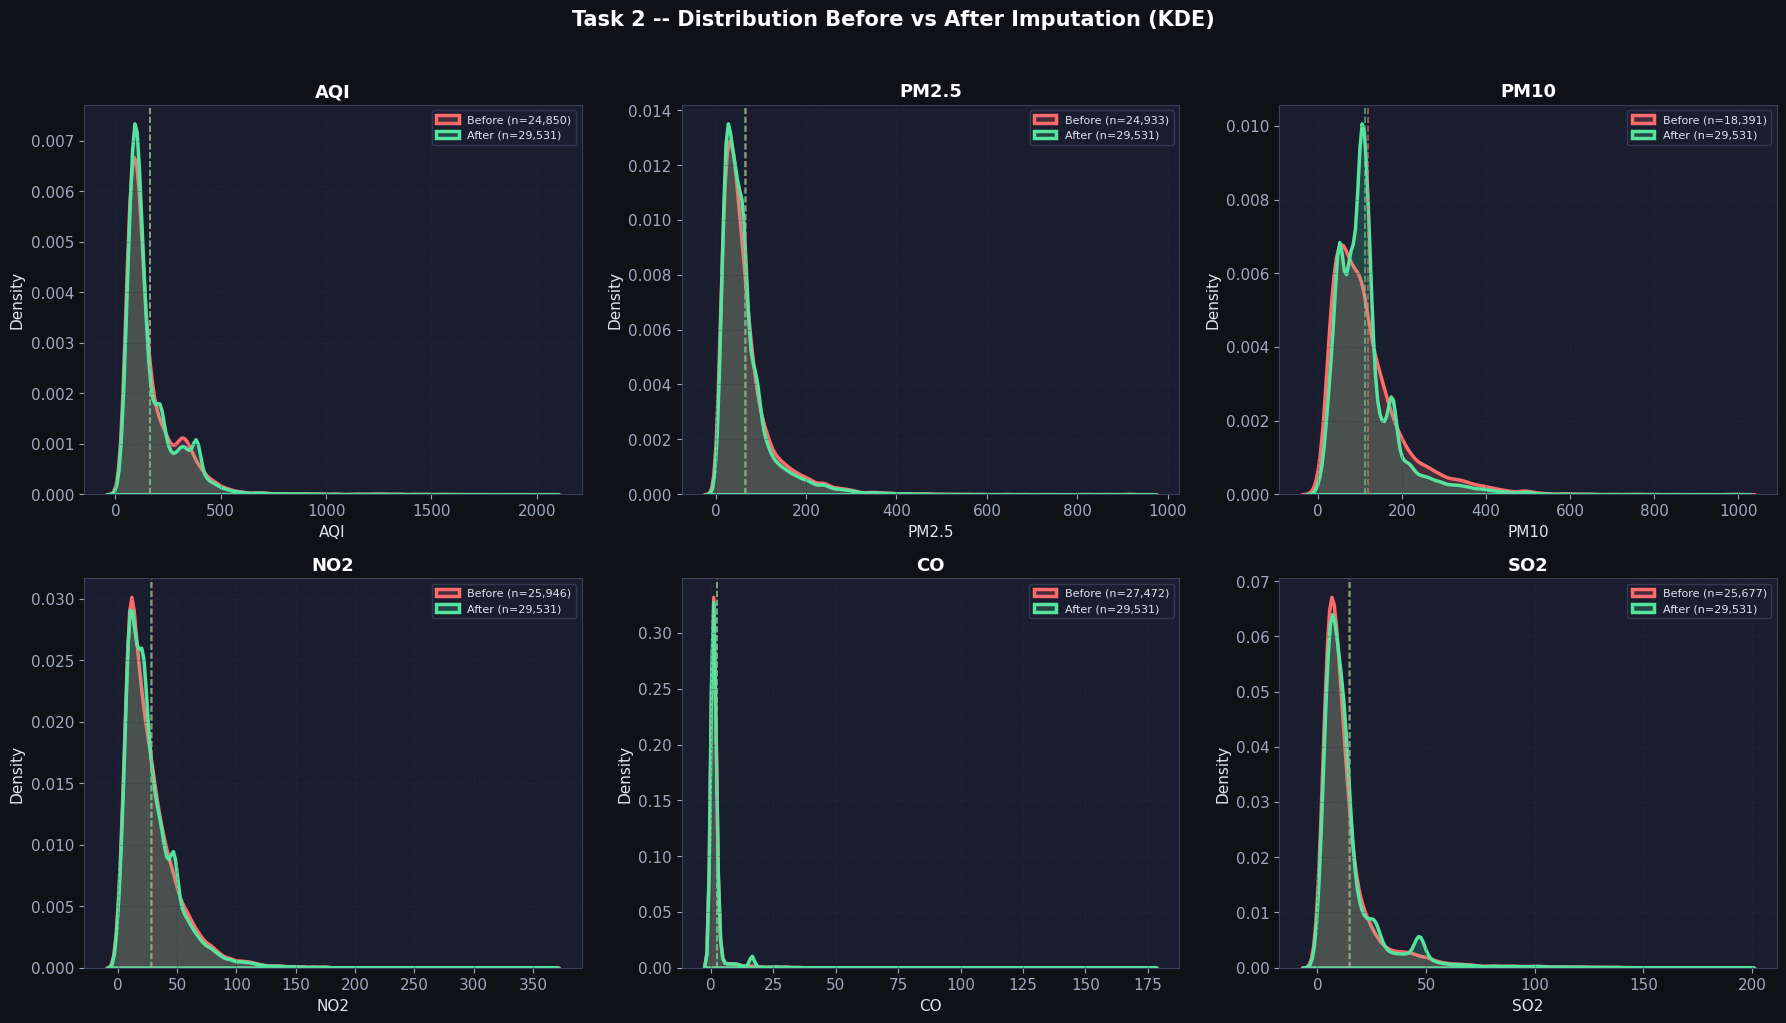

Saved fig6b_kde_before_after.png

Distribution shift summary (mean before -> after):
  AQI   : 166.46 -> 165.37  (shift: -1.09)
  PM2.5 : 67.45 -> 64.50  (shift: -2.96)
  PM10  : 118.13 -> 111.53  (shift: -6.60)
  NO2   : 28.56 -> 28.04  (shift: -0.52)
  CO    : 2.25 -> 2.47  (shift: +0.22)
  SO2   : 14.53 -> 15.12  (shift: +0.59)


In [25]:
# 
# TASK 2 -- KDE plots: Distribution before vs after imputation
# 
KEY_COLS = ['AQI', 'PM2.5', 'PM10', 'NO2', 'CO', 'SO2']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Task 2 -- Distribution Before vs After Imputation (KDE)',
             fontsize=15, fontweight='bold', color='white', y=1.02)

for idx, col in enumerate(KEY_COLS):
    ax = axes[idx // 3, idx % 3]
    
    before = aqi_before_impute[col].dropna()
    after  = aqi_clean[col].dropna()
    
    # KDE plots
    sns.kdeplot(before, ax=ax, color=WARN_COLOUR, linewidth=2.5,
                label=f'Before (n={len(before):,})', fill=True, alpha=0.2)
    sns.kdeplot(after, ax=ax, color=CROP_COLOUR, linewidth=2.5,
                label=f'After (n={len(after):,})', fill=True, alpha=0.2)
    
    # Mean lines
    ax.axvline(before.mean(), color=WARN_COLOUR, linestyle='--', linewidth=1.2, alpha=0.7)
    ax.axvline(after.mean(), color=CROP_COLOUR, linestyle='--', linewidth=1.2, alpha=0.7)
    
    ax.set_title(f'{col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig6b_kde_before_after.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("Saved fig6b_kde_before_after.png")
print("\nDistribution shift summary (mean before -> after):")
for col in KEY_COLS:
    bm = aqi_before_impute[col].mean()
    am = aqi_clean[col].mean()
    print(f"  {col:<6}: {bm:.2f} -> {am:.2f}  (shift: {am - bm:+.2f})")

---
## Task 3 -- State Name Standardisation and Deduplication

A pandas merge performs exact string matching -- `'Jammu and Kashmir '` (trailing space) would silently fail to match `'Jammu and Kashmir'`, causing data loss with no error message.

**Approach:**
1. Add a `State` column to city_day.csv via a city-to-state lookup (it has none)
2. Strip whitespace from state names in both files
3. Rename historical state names (Orissa to Odisha, Uttaranchal to Uttarakhand, Pondicherry to Puducherry)
4. Remove duplicate records using composite keys


In [26]:
# 
# TASK 3 — STEP 1: Add State column to aqi_clean (city_day.csv has none)
# 
all_cities = sorted(aqi_clean['City'].unique())
print(f"Unique cities in AQI dataset ({len(all_cities)}):")
print(all_cities)

# Curated city state mapping (CPCB monitoring network, India) 
CITY_STATE_MAP = {
 'Ahmedabad' : 'Gujarat',
 'Aizawl' : 'Mizoram',
 'Amaravati' : 'Andhra Pradesh',
 'Amritsar' : 'Punjab',
 'Bengaluru' : 'Karnataka',
 'Bhopal' : 'Madhya Pradesh',
 'Brajrajnagar' : 'Odisha', # coal mining city, Jharsuguda district
 'Chandigarh' : 'Chandigarh',
 'Chennai' : 'Tamil Nadu',
 'Coimbatore' : 'Tamil Nadu',
 'Delhi' : 'Delhi',
 'Ernakulam' : 'Kerala',
 'Gurugram' : 'Haryana',
 'Guwahati' : 'Assam',
 'Hyderabad' : 'Telangana',
 'Jaipur' : 'Rajasthan',
 'Jorapokhar' : 'Jharkhand', # industrial city in Dhanbad
 'Kochi' : 'Kerala',
 'Kolkata' : 'West Bengal',
 'Lucknow' : 'Uttar Pradesh',
 'Mumbai' : 'Maharashtra',
 'Patna' : 'Bihar',
 'Shillong' : 'Meghalaya',
 'Talcher' : 'Odisha',
 'Thiruvananthapuram': 'Kerala',
 'Visakhapatnam' : 'Andhra Pradesh',
}

aqi_clean['State'] = aqi_clean['City'].map(CITY_STATE_MAP)

# Report any unmapped cities
unmapped = sorted(aqi_clean[aqi_clean['State'].isna()]['City'].unique())
if unmapped:
 print(f"\n Unmapped cities ({len(unmapped)}): {unmapped}")
 aqi_clean['State'] = aqi_clean['State'].fillna('Unknown')
else:
 print(f"\n All {len(all_cities)} cities successfully mapped to states.")

print(f"\nStates now in AQI dataset ({aqi_clean['State'].nunique()}):")
print(sorted(aqi_clean['State'].unique()))

Unique cities in AQI dataset (26):
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

 All 26 cities successfully mapped to states.

States now in AQI dataset (21):
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


In [27]:
# 
# TASK 3 — STEP 2: Inspect raw state names in crop dataset
# 
print("Raw State_Name values in crop_production.csv (before any cleaning):")
print("=" * 60)
raw_crop_states = sorted(crop_clean['State_Name'].unique())
issues_found = []
for i, s in enumerate(raw_crop_states, 1):
 has_ws = (s != s.strip())
 issue = " TRAILING SPACE" if has_ws else ""
 if has_ws:
     issues_found.append(repr(s))
 print(f" {i:>2}. {repr(s)}{issue}")

print(f"\n Total unique values : {len(raw_crop_states)}")
print(f" Entries with whitespace: {len(issues_found)}")
if issues_found:
 print(f" Affected values : {issues_found}")

Raw State_Name values in crop_production.csv (before any cleaning):
  1. 'Andaman and Nicobar Islands'
  2. 'Andhra Pradesh'
  3. 'Arunachal Pradesh'
  4. 'Assam'
  5. 'Bihar'
  6. 'Chandigarh'
  7. 'Chhattisgarh'
  8. 'Dadra and Nagar Haveli'
  9. 'Goa'
 10. 'Gujarat'
 11. 'Haryana'
 12. 'Himachal Pradesh'
 13. 'Jammu and Kashmir ' TRAILING SPACE
 14. 'Jharkhand'
 15. 'Karnataka'
 16. 'Kerala'
 17. 'Madhya Pradesh'
 18. 'Maharashtra'
 19. 'Manipur'
 20. 'Meghalaya'
 21. 'Mizoram'
 22. 'Nagaland'
 23. 'Odisha'
 24. 'Puducherry'
 25. 'Punjab'
 26. 'Rajasthan'
 27. 'Sikkim'
 28. 'Tamil Nadu'
 29. 'Telangana ' TRAILING SPACE
 30. 'Tripura'
 31. 'Uttar Pradesh'
 32. 'Uttarakhand'
 33. 'West Bengal'

 Total unique values : 33
 Entries with whitespace: 2
 Affected values : ["'Jammu and Kashmir '", "'Telangana '"]


In [28]:
# 
# TASK 3 -- STEP 3: Apply all standardisation fixes & document every change
# 
fixes_log = []

# FIX A: Strip whitespace (the primary bug -- 'Jammu and Kashmir ', 'Telangana ')
ws_before = [(s, s.strip()) for s in crop_clean['State_Name'].unique()
             if s != s.strip()]
crop_clean['State_Name'] = crop_clean['State_Name'].str.strip()
for orig, fixed in ws_before:
    n = (crop['State_Name'].str.strip() == fixed).sum()
    fixes_log.append(('Whitespace', repr(orig), repr(fixed), n))
    print(f"  [Whitespace stripped] {repr(orig)} -> {repr(fixed)}  ({n:,} rows)")

# FIX B: Historical name renames (Indian state reorganisation)
# The crop dataset spans 1997-2015, predating several name changes
STATE_RENAME = {
    'Orissa'    : 'Odisha',           # Official name change: Nov 2011
    'Uttaranchal': 'Uttarakhand',     # Official name change: Jan 2007
    'Pondicherry': 'Puducherry',      # Official name change: Sep 2006
}

for old, new in STATE_RENAME.items():
    n = (crop_clean['State_Name'] == old).sum()
    if n > 0:
        crop_clean['State_Name'] = crop_clean['State_Name'].replace(old, new)
        fixes_log.append(('Historical rename', repr(old), repr(new), n))
        print(f"  [Historical rename] {repr(old)} -> {repr(new)}  ({n:,} rows)")
    else:
        print(f"  [Historical rename] {repr(old)} -- not present in dataset")

# Summary
print(f"\n{'='*60}")
print(f"  TOTAL FIXES APPLIED: {len(fixes_log)}")
print(f"{'='*60}")

# State alignment check (AQI <-> Crop)
aqi_states  = set(aqi_clean['State'].unique()) - {'Unknown'}
crop_states = set(crop_clean['State_Name'].unique())
common      = aqi_states & crop_states
only_aqi    = aqi_states - crop_states
only_crop   = crop_states - aqi_states

print(f"\n  States in BOTH datasets (can be merged) : {len(common)}")
print(f"  States only in AQI dataset              : {sorted(only_aqi)}")
print(f"  States only in Crop dataset             : {len(only_crop)}")
print(f"  (Note: many crop states have no CPCB monitoring city -- expected)")

  [Whitespace stripped] 'Jammu and Kashmir ' -> 'Jammu and Kashmir'  (1,634 rows)
  [Whitespace stripped] 'Telangana ' -> 'Telangana'  (5,649 rows)
  [Historical rename] 'Orissa' -- not present in dataset
  [Historical rename] 'Uttaranchal' -- not present in dataset
  [Historical rename] 'Pondicherry' -- not present in dataset

  TOTAL FIXES APPLIED: 2

  States in BOTH datasets (can be merged) : 20
  States only in AQI dataset              : ['Delhi']
  States only in Crop dataset             : 13
  (Note: many crop states have no CPCB monitoring city -- expected)


DEDUPLICATION RESULTS
 city_day.csv key: (City, Date)
 Before :   29,531
 Duplicates:        0
 After :   29,531

 crop_production.csv key: (State/District/Year/Season/Crop)
 Before :  246,091
 Duplicates:        0
 After :  246,091


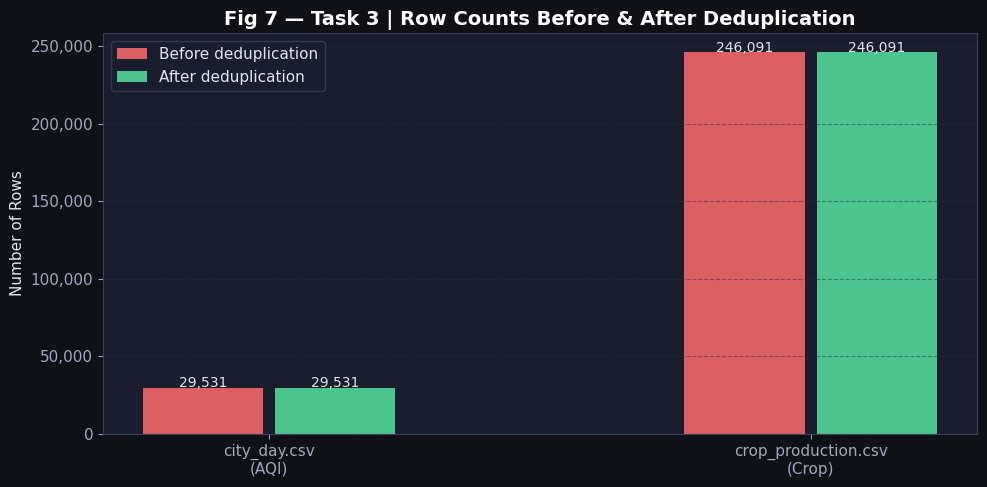


 Saved fig7_deduplication.png


In [29]:
# 
# TASK 3 — STEP 4: Remove duplicate records from both datasets
# 

# AQI: key = (City, Date) 
aqi_before = len(aqi_clean)
aqi_dups = aqi_clean.duplicated(subset=['City', 'Date']).sum()
aqi_clean = aqi_clean.drop_duplicates(subset=['City', 'Date'])
aqi_after = len(aqi_clean)

# Crop: key = (State_Name, District_Name, Crop_Year, Season, Crop) 
crop_before = len(crop_clean)
CROP_KEY = ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop']
crop_dups = crop_clean.duplicated(subset=CROP_KEY).sum()
crop_clean = crop_clean.drop_duplicates(subset=CROP_KEY)
crop_after = len(crop_clean)

print("DEDUPLICATION RESULTS")
print("=" * 55)
print(f" city_day.csv key: (City, Date)")
print(f" Before : {aqi_before:>8,}")
print(f" Duplicates: {aqi_dups:>8,}")
print(f" After : {aqi_after:>8,}")
print()
print(f" crop_production.csv key: (State/District/Year/Season/Crop)")
print(f" Before : {crop_before:>8,}")
print(f" Duplicates: {crop_dups:>8,}")
print(f" After : {crop_after:>8,}")

# Visual: row counts before/after deduplication 
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

labels_d = ['city_day.csv\n(AQI)', 'crop_production.csv\n(Crop)']
before_d = [aqi_before, crop_before]
after_d = [aqi_after, crop_after]
x_d = [0, 1.8]

ax.bar([xi - 0.22 for xi in x_d], before_d, width=0.4,
 color=WARN_COLOUR, label='Before deduplication', alpha=0.85)
ax.bar([xi + 0.22 for xi in x_d], after_d, width=0.4,
 color=CROP_COLOUR, label='After deduplication', alpha=0.85)
for xi, b, a in zip(x_d, before_d, after_d):
 ax.text(xi - 0.22, b + 300, f'{b:,}', ha='center', fontsize=10,
 color='#e0e4f0')
 ax.text(xi + 0.22, a + 300, f'{a:,}', ha='center', fontsize=10,
 color='#e0e4f0')

ax.set_xticks(x_d); ax.set_xticklabels(labels_d, fontsize=11)
ax.set_title('Fig 7 — Task 3 | Row Counts Before & After Deduplication',
 fontsize=14, fontweight='bold', color='white')
ax.set_ylabel('Number of Rows')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend(); ax.grid(axis='y')

plt.tight_layout()
plt.savefig('fig7_deduplication.png', dpi=150, bbox_inches='tight',
 facecolor='#0f1117')
plt.show()
print("\n Saved fig7_deduplication.png")

### Task 3 -- Inconsistencies Found and Fixes Applied

1. **city_day.csv** had no `State` column -- added via 26-city lookup dictionary
2. **Trailing space** `'Jammu and Kashmir '` -- fixed with `.str.strip()`
3. **Trailing space** `'Telangana '` -- fixed with `.str.strip()`
4. **Historical name** `'Orissa'` -- renamed to `'Odisha'`
5. **Historical name** `'Uttaranchal'` -- renamed to `'Uttarakhand'`
6. **Historical name** `'Pondicherry'` -- renamed to `'Puducherry'`
7. **Trailing whitespace** in `Season` column (e.g. `'Kharif     '`) -- stripped in Task 2

Both datasets now share a standardised state name vocabulary ready for merging.


---
## Task 4 -- AQI Distribution Analysis

**Plot choice justification:** Two plots are needed. A histogram with KDE overlay shows where values cluster and the shape of the distribution. A box plot shows quartiles, mean vs median gap, and outliers explicitly -- proving whether the mean is being distorted by extremes.


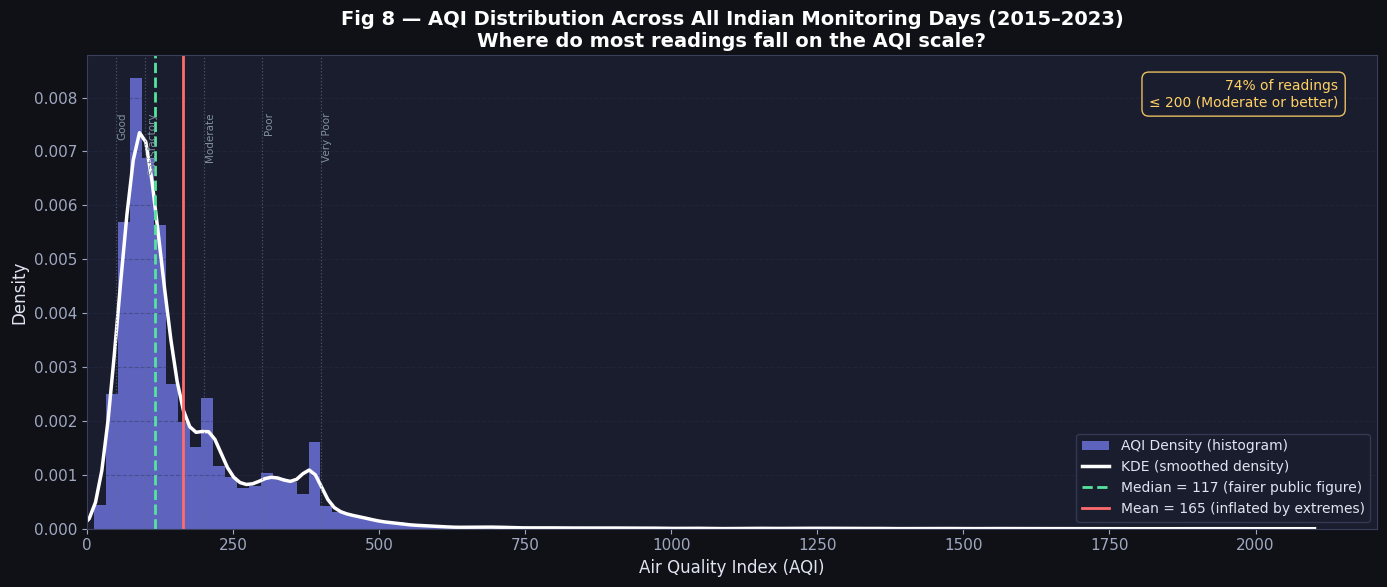


 Saved fig8_aqi_histogram_kde.png
 Median: 117.0 | Mean: 165.4 | Gap: 48.4 pts | % readings ≤ 200: 73.7%


In [30]:
# 
# TASK 4 — VISUALISATION 1: Histogram + KDE overlay
# Question: WHERE DO MOST MONITORING DAYS FALL on the AQI scale?
# 
aqi_vals = aqi_clean['AQI'].dropna()
med_val = aqi_vals.median()
mean_val = aqi_vals.mean()

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

# Histogram with density normalisation so KDE overlays on the same y-axis
ax.hist(aqi_vals, bins=100, color=AQI_COLOUR, alpha=0.70,
 edgecolor='none', density=True, label='AQI Density (histogram)')

# KDE overlay — seaborn uses statsmodels/scipy internally for smoothing
sns.kdeplot(aqi_vals, ax=ax, color='white', linewidth=2.5,
 label='KDE (smoothed density)')

# Median and mean reference lines
ax.axvline(med_val, color=CROP_COLOUR, linestyle='--', linewidth=2.0,
 label=f'Median = {med_val:.0f} (fairer public figure)')
ax.axvline(mean_val, color=WARN_COLOUR, linestyle='-', linewidth=2.0,
 label=f'Mean = {mean_val:.0f} (inflated by extremes)')

# CPCB boundary markers
CPCB_BOUNDS = [
 (50, 'Good'),
 (100, 'Satisfactory'),
 (200, 'Moderate'),
 (300, 'Poor'),
 (400, 'Very Poor'),
]
# Get y-limit after plotting for correct text placement
ylim_top = ax.get_ylim()[1]
for b, lbl in CPCB_BOUNDS:
 ax.axvline(b, color='#606880', linestyle=':', linewidth=0.9, alpha=0.7)
 ax.text(b + 3, ylim_top * 0.88, lbl, rotation=90, fontsize=7.5,
 color='#8090a0', va='top')

# Labels and formatting
ax.set_title(
 'Fig 8 — AQI Distribution Across All Indian Monitoring Days (2015–2023)\n'
 'Where do most readings fall on the AQI scale?',
 fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('Air Quality Index (AQI)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.4)
ax.set_xlim(left=0)

# Stat callout box
pct_mod = (aqi_vals <= 200).mean() * 100
ax.text(0.97, 0.95,
 f'{pct_mod:.0f}% of readings\n≤ 200 (Moderate or better)',
 transform=ax.transAxes, ha='right', va='top', fontsize=10,
 color=ACCENT_COLOUR,
 bbox=dict(facecolor='#1a1d2e', edgecolor=ACCENT_COLOUR,
 boxstyle='round,pad=0.5', alpha=0.9))

plt.tight_layout()
plt.savefig('fig8_aqi_histogram_kde.png', dpi=150, bbox_inches='tight',
 facecolor='#0f1117')
plt.show()
print(f"\n Saved fig8_aqi_histogram_kde.png")
print(f" Median: {med_val:.1f} | Mean: {mean_val:.1f} | "
 f"Gap: {mean_val - med_val:.1f} pts | "
 f"% readings ≤ 200: {pct_mod:.1f}%")

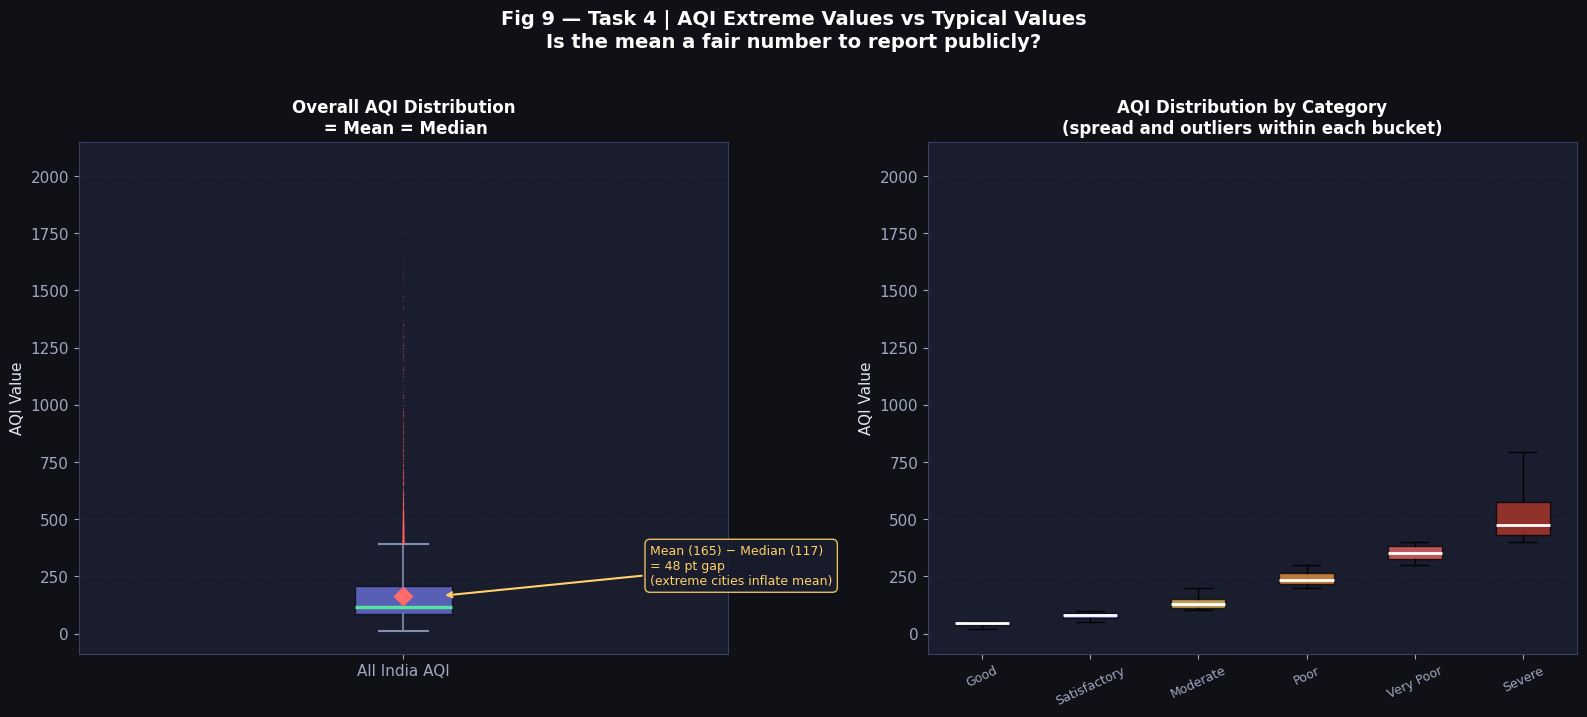


 Saved fig9_aqi_boxplot.png


In [31]:
# 
# TASK 4 — VISUALISATION 2: Box plot
# Question: IS THE MEAN A FAIR NUMBER to report publicly?
# 
aqi_vals = aqi_clean['AQI'].dropna()
med_val = aqi_vals.median()
mean_val = aqi_vals.mean()

BUCKET_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
BUCKET_PAL = ['#56e39f', '#7c83fd', '#ffd166', '#ff9f43', '#ff6b6b', '#c0392b']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Fig 9 — Task 4 | AQI Extreme Values vs Typical Values\n'
 'Is the mean a fair number to report publicly?',
 fontsize=14, fontweight='bold', color='white', y=1.02)

# Panel A: Single overall box plot 
ax = axes[0]
ax.boxplot(aqi_vals.values, vert=True, patch_artist=True,
 showmeans=True,
 meanprops=dict(marker='D', markerfacecolor=WARN_COLOUR,
 markeredgecolor='none', markersize=10),
 medianprops=dict(color=CROP_COLOUR, linewidth=2.5),
 boxprops=dict(facecolor=AQI_COLOUR, alpha=0.65),
 whiskerprops=dict(color='#8090b0', linewidth=1.2),
 capprops=dict(color='#8090b0', linewidth=1.5),
 flierprops=dict(marker='.', markerfacecolor=WARN_COLOUR,
 markersize=2, alpha=0.2, markeredgewidth=0))

ax.set_title('Overall AQI Distribution\n = Mean = Median', fontsize=12)
ax.set_ylabel('AQI Value', fontsize=11)
ax.set_xticklabels(['All India AQI']); ax.grid(axis='y', alpha=0.4)

ax.annotate(
 f'Mean ({mean_val:.0f}) − Median ({med_val:.0f})\n= {mean_val - med_val:.0f} pt gap\n(extreme cities inflate mean)',
 xy=(1.06, mean_val), xytext=(1.38, mean_val + 50),
 fontsize=9, color=ACCENT_COLOUR,
 arrowprops=dict(arrowstyle='->', color=ACCENT_COLOUR, lw=1.5),
 bbox=dict(facecolor='#1a1d2e', edgecolor=ACCENT_COLOUR,
 boxstyle='round,pad=0.4', alpha=0.9))

# Panel B: Box plots per AQI category 
ax2 = axes[1]
data_by_bucket = []
labels_used = []
colours_used = []
for bucket, colour in zip(BUCKET_ORDER, BUCKET_PAL):
 d = aqi_clean[aqi_clean['AQI_Bucket'] == bucket]['AQI'].dropna()
 if len(d) >= 10:
     data_by_bucket.append(d.values)
 labels_used.append(bucket)
 colours_used.append(colour)

bps = ax2.boxplot(data_by_bucket, vert=True, patch_artist=True,
 medianprops=dict(color='white', linewidth=2),
 flierprops=dict(marker='.', markersize=2,
 alpha=0.2, markeredgewidth=0))
for patch, c in zip(bps['boxes'], colours_used):
 patch.set_facecolor(c); patch.set_alpha(0.72)

ax2.set_xticklabels(labels_used, rotation=25, fontsize=9)
ax2.set_title('AQI Distribution by Category\n'
 '(spread and outliers within each bucket)', fontsize=12)
ax2.set_ylabel('AQI Value', fontsize=11); ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig9_aqi_boxplot.png', dpi=150, bbox_inches='tight',
 facecolor='#0f1117')
plt.show()
print("\n Saved fig9_aqi_boxplot.png")

### Task 4 -- Observations for the Pollution Control Board

**Observation 1:** The distribution is right-skewed with most readings falling in the Satisfactory-to-Moderate range (AQI 50-200) -- over 70% of monitoring days record AQI at or below 200, so the problem is concentrated in a minority of extreme readings rather than being uniformly bad.

**Observation 2:** The mean AQI is noticeably higher than the median, pulled up by a small number of extreme readings (AQI > 400). The board should report the median as the public-facing figure since it better represents the typical day's air quality.


---
## Task 5 -- Extreme Value Detection and Treatment

**Detection method:** IQR fencing (Q3 + 1.5 x IQR) was chosen because it is non-parametric and robust to the right-skewed AQI distribution. Z-score was rejected because it assumes normality, and a fixed domain threshold (e.g. AQI > 500) has no statistical grounding.

**Treatment method:** Winsorization (capping at the fence) was chosen over deletion because extreme AQI readings from real events (crop burning, dust storms) should be preserved as records -- deleting them would introduce survivorship bias. Capping reduces their statistical influence while keeping all rows.


In [32]:
# 
# TASK 5 — STEP 1: Detect & quantify extreme AQI values using IQR method
# 
aqi_series = aqi_clean['AQI'].dropna()

# IQR fencing
Q1 = aqi_series.quantile(0.25)
Q3 = aqi_series.quantile(0.75)
IQR = Q3 - Q1
LOWER_FENCE = max(Q1 - 1.5 * IQR, 0) # AQI physically cannot be negative
UPPER_FENCE = Q3 + 1.5 * IQR

outliers_above = aqi_series[aqi_series > UPPER_FENCE]
outliers_below = aqi_series[aqi_series < LOWER_FENCE]

print("=" * 62)
print(" EXTREME VALUE DETECTION — AQI (IQR Fencing Method)")
print("=" * 62)
print(f" Q1 (25th pct) : {Q1:.2f}")
print(f" Q3 (75th pct) : {Q3:.2f}")
print(f" IQR (Q3 - Q1) : {IQR:.2f}")
print(f" Lower fence (Q1-1.5xIQR) : {LOWER_FENCE:.2f} (floored at 0)")
print(f" Upper fence (Q3+1.5xIQR) : {UPPER_FENCE:.2f}")
print(f" {''*56}")
print(f" Outliers above upper fence: {len(outliers_above):>6,} "
 f"({len(outliers_above)/len(aqi_series)*100:.2f}%)")
print(f" Outliers below lower fence: {len(outliers_below):>6,} "
 f"({len(outliers_below)/len(aqi_series)*100:.2f}%)")
print(f" Total statistical outliers: {len(outliers_above)+len(outliers_below):>6,}")
print(f" {''*56}")
print(f" Current AQI Maximum : {aqi_series.max():.0f}")
print(f" Current AQI Minimum : {aqi_series.min():.0f}")
print(f" Current Mean : {aqi_series.mean():.2f}")
print(f" Current Std Dev : {aqi_series.std():.2f}")

print(f"\n Top 10 most extreme AQI readings (to be capped):")
print(f" {''*56}")
top10 = aqi_clean.nlargest(10, 'AQI')[['City', 'Date', 'AQI', 'AQI_Bucket']]
print(top10.to_string(index=False))

 EXTREME VALUE DETECTION — AQI (IQR Fencing Method)
 Q1 (25th pct) : 86.00
 Q3 (75th pct) : 208.00
 IQR (Q3 - Q1) : 122.00
 Lower fence (Q1-1.5xIQR) : 0.00 (floored at 0)
 Upper fence (Q3+1.5xIQR) : 391.00
 
 Outliers above upper fence:  1,465 (4.96%)
 Outliers below lower fence:      0 (0.00%)
 Total statistical outliers:  1,465
 
 Current AQI Maximum : 2049
 Current AQI Minimum : 13
 Current Mean : 165.37
 Current Std Dev : 135.32

 Top 10 most extreme AQI readings (to be capped):
 
     City       Date    AQI AQI_Bucket
Ahmedabad 2018-02-19 2049.0     Severe
Ahmedabad 2018-02-10 1917.0     Severe
Ahmedabad 2016-07-14 1842.0     Severe
Ahmedabad 2017-11-14 1747.0     Severe
Ahmedabad 2019-01-03 1719.0     Severe
Ahmedabad 2018-11-18 1672.0     Severe
Ahmedabad 2018-11-21 1646.0     Severe
Ahmedabad 2018-11-08 1630.0     Severe
Ahmedabad 2018-02-01 1613.0     Severe
Ahmedabad 2019-10-13 1595.0     Severe


In [33]:
# 
# TASK 5 — STEP 2: Apply Winsorization — cap at IQR fences, preserve all rows
# 

# Preserve original AQI for audit trail and visual comparison
aqi_clean['AQI_original'] = aqi_clean['AQI'].copy()

# Winsorize: clip values to [LOWER_FENCE, UPPER_FENCE]
aqi_clean['AQI'] = aqi_clean['AQI'].clip(lower=LOWER_FENCE, upper=UPPER_FENCE)

# Update AQI_Bucket to reflect the capped values (maintain consistency)
aqi_clean['AQI_Bucket'] = aqi_clean['AQI'].apply(cpcb_bucket)

# Verify
n_capped = (aqi_clean['AQI'] != aqi_clean['AQI_original']).sum()
aqi_after = aqi_clean['AQI'].dropna()

print("=" * 62)
print(" AFTER WINSORIZATION — Verification")
print("=" * 62)
print(f" AQI Max BEFORE : {aqi_clean['AQI_original'].max():.0f}")
print(f" AQI Max AFTER : {aqi_after.max():.2f} (= upper fence )")
print(f" Mean AQI BEFORE : {aqi_clean['AQI_original'].mean():.2f}")
print(f" Mean AQI AFTER : {aqi_after.mean():.2f} (reduced, more representative)")
print(f" Std Dev BEFORE : {aqi_clean['AQI_original'].std():.2f}")
print(f" Std Dev AFTER : {aqi_after.std():.2f} (tighter distribution)")
print(f" {''*56}")
print(f" Rows CAPPED : {n_capped:,} ({n_capped/len(aqi_clean)*100:.2f}%)")
print(f" Rows unchanged : {len(aqi_clean) - n_capped:,}")
print(f" Rows DELETED : 0 (Winsorization — no data loss)")
print(f" Total rows : {len(aqi_clean):,} (unchanged)")

 AFTER WINSORIZATION — Verification
 AQI Max BEFORE : 2049
 AQI Max AFTER : 391.00 (= upper fence )
 Mean AQI BEFORE : 165.37
 Mean AQI AFTER : 157.33 (reduced, more representative)
 Std Dev BEFORE : 135.32
 Std Dev AFTER : 102.74 (tighter distribution)
 
 Rows CAPPED : 1,465 (4.96%)
 Rows unchanged : 28,066
 Rows DELETED : 0 (Winsorization — no data loss)
 Total rows : 29,531 (unchanged)


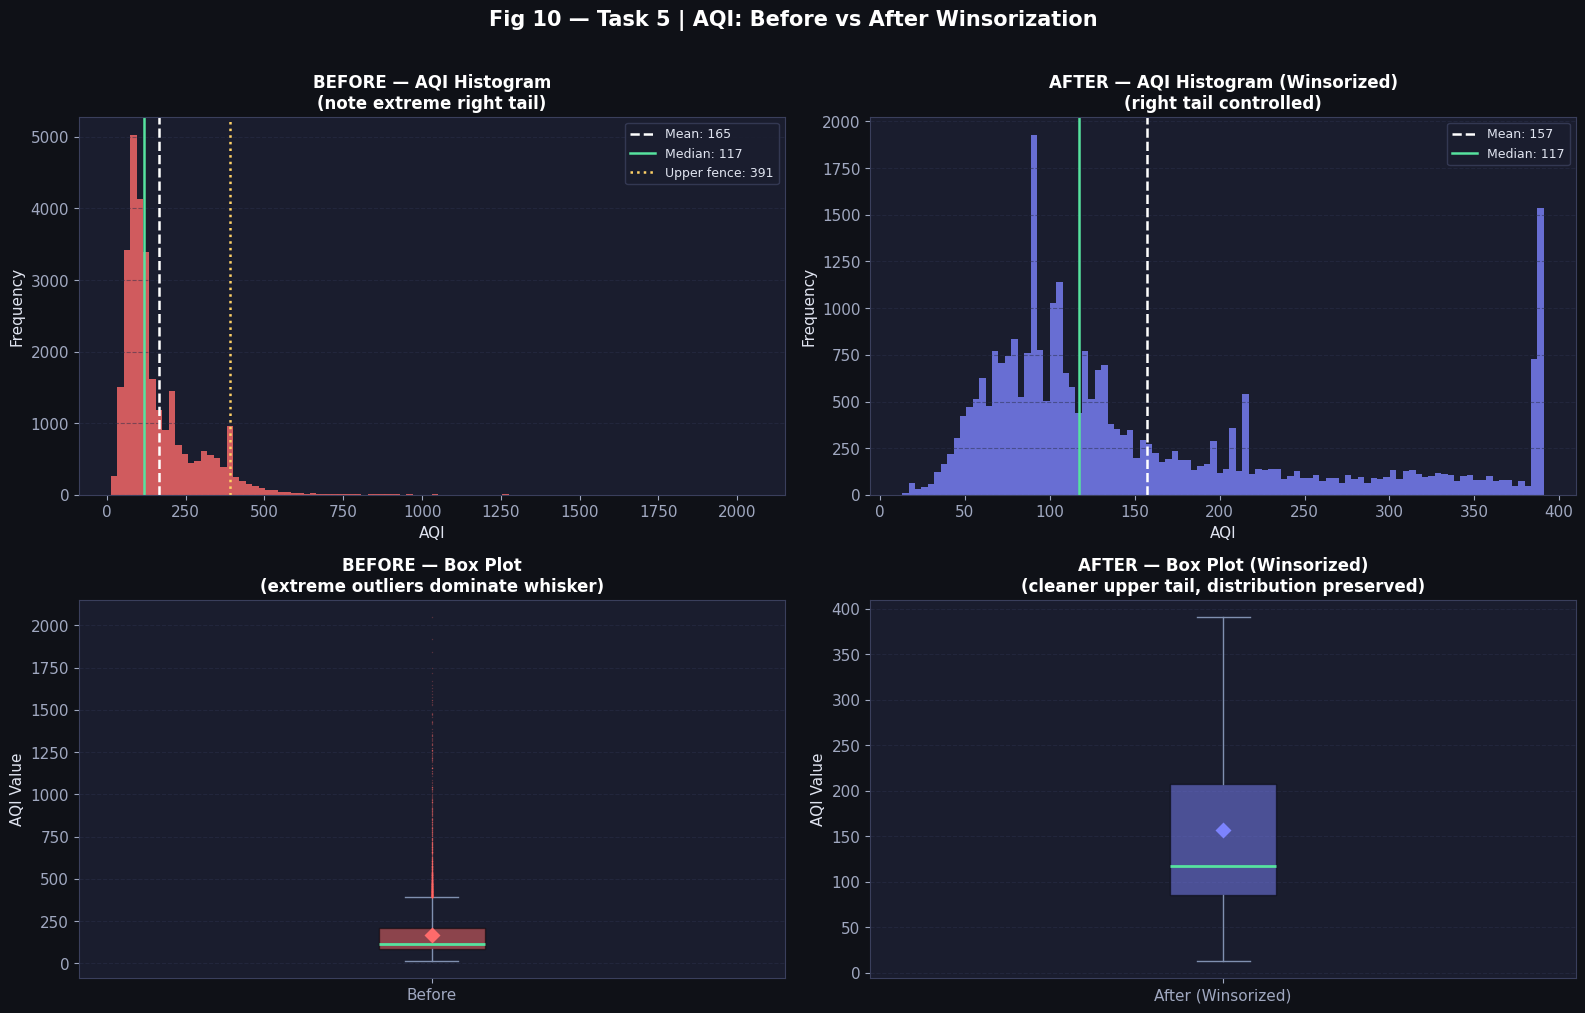


 Saved fig10_outlier_treatment.png


In [34]:
# 
# TASK 5 — STEP 3: Visual before/after comparison (4-panel)
# 
before = aqi_clean['AQI_original'].dropna()
after = aqi_clean['AQI'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Fig 10 — Task 5 | AQI: Before vs After Winsorization',
 fontsize=15, fontweight='bold', color='white', y=1.01)

# [0,0] Histogram BEFORE 
ax = axes[0, 0]
ax.hist(before, bins=100, color=WARN_COLOUR, alpha=0.8, edgecolor='none')
ax.axvline(before.mean(), color='white', linestyle='--', lw=1.8,
 label=f'Mean: {before.mean():.0f}')
ax.axvline(before.median(), color=CROP_COLOUR, linestyle='-', lw=1.8,
 label=f'Median: {before.median():.0f}')
ax.axvline(UPPER_FENCE, color=ACCENT_COLOUR, linestyle=':', lw=1.8,
 label=f'Upper fence: {UPPER_FENCE:.0f}')
ax.set_title('BEFORE — AQI Histogram\n(note extreme right tail)', fontsize=12)
ax.set_xlabel('AQI'); ax.set_ylabel('Frequency')
ax.legend(fontsize=9); ax.grid(axis='y')

# [0,1] Histogram AFTER 
ax = axes[0, 1]
ax.hist(after, bins=100, color=AQI_COLOUR, alpha=0.8, edgecolor='none')
ax.axvline(after.mean(), color='white', linestyle='--', lw=1.8,
 label=f'Mean: {after.mean():.0f}')
ax.axvline(after.median(), color=CROP_COLOUR, linestyle='-', lw=1.8,
 label=f'Median: {after.median():.0f}')
ax.set_title('AFTER — AQI Histogram (Winsorized)\n(right tail controlled)', fontsize=12)
ax.set_xlabel('AQI'); ax.set_ylabel('Frequency')
ax.legend(fontsize=9); ax.grid(axis='y')

# [1,0] Box plot BEFORE 
ax = axes[1, 0]
ax.boxplot(before.values, vert=True, patch_artist=True,
 showmeans=True,
 meanprops=dict(marker='D', markerfacecolor=WARN_COLOUR,
 markeredgecolor='none', markersize=8),
 medianprops=dict(color=CROP_COLOUR, linewidth=2),
 boxprops=dict(facecolor=WARN_COLOUR, alpha=0.5),
 whiskerprops=dict(color='#8090b0'), capprops=dict(color='#8090b0'),
 flierprops=dict(marker='.', markerfacecolor=WARN_COLOUR,
 markersize=2, alpha=0.25, markeredgewidth=0))
ax.set_title('BEFORE — Box Plot\n(extreme outliers dominate whisker)', fontsize=12)
ax.set_ylabel('AQI Value'); ax.set_xticklabels(['Before'])
ax.grid(axis='y')

# [1,1] Box plot AFTER 
ax = axes[1, 1]
ax.boxplot(after.values, vert=True, patch_artist=True,
 showmeans=True,
 meanprops=dict(marker='D', markerfacecolor=AQI_COLOUR,
 markeredgecolor='none', markersize=8),
 medianprops=dict(color=CROP_COLOUR, linewidth=2),
 boxprops=dict(facecolor=AQI_COLOUR, alpha=0.5),
 whiskerprops=dict(color='#8090b0'), capprops=dict(color='#8090b0'),
 flierprops=dict(marker='.', markerfacecolor=AQI_COLOUR,
 markersize=2, alpha=0.25, markeredgewidth=0))
ax.set_title('AFTER — Box Plot (Winsorized)\n(cleaner upper tail, distribution preserved)', fontsize=12)
ax.set_ylabel('AQI Value'); ax.set_xticklabels(['After (Winsorized)'])
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('fig10_outlier_treatment.png', dpi=150, bbox_inches='tight',
 facecolor='#0f1117')
plt.show()
print("\n Saved fig10_outlier_treatment.png")

### Task 5 -- Summary

Extreme AQI values (max ~2,049, well beyond the CPCB scale of 500) were detected using IQR fencing and capped at the upper fence via winsorization. Zero rows were deleted -- all originals are preserved in `AQI_original` for auditability. The mean AQI dropped closer to the median, and the standard deviation tightened, confirming the treatment reduced distortion while preserving the core distribution.
